# MAE-HID SSL Ablation Visualization

HID counterpart to `consolidated_visualization.ipynb` (the HAR notebook). Same overall structure
(A0/A mask ratio, B/D mask strategy, C/E patch size, each at enc6/enc12) and the same
`load_matching_results` / completeness-diagnostic / best-layer-per-group machinery, adapted for
two things that are genuinely different about HID rather than assumed identical to HAR:

1. **`task_prefix="mae_hid"`** instead of `"mae_har"` (confirmed from your file audit: HID runs
   live under `mae_hid/`, `exp` names start with `mae_hid_`, and -- unlike HAR's `ep300` -- your HID
   runs are `ep150`. The loader filters by `exp` prefix, not epoch count, so this difference
   doesn't need special-casing, just noting.)
2. **Unknown metric schema.** HAR's `evals` entries have `knn_acc`/`lp_acc`/`knn_f1`/`lp_f1`, and
   because they're all "accuracy-like" it was valid to take a max across them to find a "best
   protocol". HID's real metrics are unconfirmed here -- per project notes they likely include
   things like closed-set accuracy, open-set Rank-1, and Verification AUC, which are **not on the
   same scale and must not be maxed against each other** (an AUC of 0.75 is not "worse" than a
   Rank-1 of 99% -- they're different measurements). So **Step 0 below inspects one real file and
   prints exactly what metric keys exist** before anything downstream assumes a name, and every
   "best layer" table here is built **per individual metric**, never by comparing across metrics.

**Also worth carrying over from project notes:** `test_cross_user` may be a degenerate single-identity
split for HID (Rank-1 trivially 100%, Verification AUC undefined/NaN because there are no negative
pairs). If Step 0 or the completeness check below flags `test_cross_user` as "missing" a metric,
that may be this expected degeneracy rather than a corrupted file -- the completeness cell notes
this explicitly rather than treating it as an error.

Edit `RESULTS_DIR` / `FIG_DIR` below before running.


In [1]:

import json
import re
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

# -- Paths ----------------------------------------------------------------
RESULTS_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/results")  # parent dir (same as HAR notebook)
FIG_DIR = Path("/home/zhuzih19/csi-project/csi-fall-detection/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLITS = ["test_id", "test_cross_device", "test_cross_env", "test_cross_user"]
SPLIT_LABELS = {
    "test_id": "ID (in-distribution)",
    "test_cross_device": "Cross-Device",
    "test_cross_env": "Cross-Env",
    "test_cross_user": "Cross-User (possibly degenerate for HID -- see notes)",
}


In [2]:

def load_matching_results(directory, filters, debug=False, task_prefix="mae_hid"):
    # Recursively load all *.json result files under `directory` whose `args` dict matches
    # every key/value in `filters`. task_prefix guards against other tasks (e.g. mae_har)
    # being picked up just because RESULTS_DIR is a shared parent directory -- see the HAR
    # notebook's file-audit discussion for why this matters.
    results = []
    candidates = sorted(Path(directory).rglob("*.json"))
    if debug:
        print(f"[debug] found {len(candidates)} .json files under {directory} (recursive)")

    for fp in candidates:
        try:
            data = json.loads(fp.read_text())
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            if debug:
                print(f"[skip] {fp.name}: failed to parse ({e})")
            continue

        exp_name = data.get("exp", "")
        if task_prefix is not None and not exp_name.startswith(task_prefix):
            if debug:
                print(f"[skip] {fp.name}: exp={exp_name!r} does not start with "
                      f"task_prefix={task_prefix!r}")
            continue

        args = data.get("args")
        if args is None:
            if debug:
                print(f"[skip] {fp.name}: no args key")
            continue

        reasons = []
        for key, expected in filters.items():
            if expected is None:
                continue
            actual = args.get(key)
            if actual is None:
                reasons.append(f"{key} missing from args")
                continue
            try:
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        reasons.append(f"{key}={actual!r} != {expected}")
                elif isinstance(expected, int) and not isinstance(expected, bool):
                    if int(actual) != expected:
                        reasons.append(f"{key}={actual!r} != {expected}")
                else:
                    if str(actual) != str(expected):
                        reasons.append(f"{key}={actual!r} != {expected!r}")
            except (TypeError, ValueError):
                reasons.append(f"{key}={actual!r} not comparable to {expected!r}")

        if reasons:
            if debug:
                print(f"[skip] {fp.name}: " + "; ".join(reasons))
            continue

        if debug:
            print(f"[match] {fp.name}")
        results.append(data)
    return results


def group_by(results, key_fn):
    groups = defaultdict(list)
    for r in results:
        groups[key_fn(r)].append(r)
    return dict(groups)


def get_layers(result):
    first_ckpt = next(iter(result["evals"].values()))
    layers = list(first_ckpt.keys())
    layers.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return layers


def get_checkpoints(result):
    ckpts = list(result["evals"].keys())
    ckpts.sort(key=lambda x: int(re.search(r"\d+", x).group()))
    return ckpts


## Step 0 -- Inspect one real HID file's metric schema (do this before anything else)

Loads a single HID file with the loosest possible filter (just `task_prefix`) and prints exactly
what metric keys exist in `evals[checkpoint][layer][split]`, for every split separately (since
`test_cross_user` may legitimately have a different key set than the others if it's the degenerate
single-identity case). **Read this output before trusting any cell below** -- it tells you what to
put in `PRIMARY_METRICS` in the next cell.


In [3]:

SCHEMA_PROBE_FILTERS = {}  # no constraints -- just grab any mae_hid file to inspect
_probe_results = load_matching_results(RESULTS_DIR, SCHEMA_PROBE_FILTERS, debug=False, task_prefix="mae_hid")

if not _probe_results:
    print("No mae_hid files found at all under RESULTS_DIR -- check the path before continuing.")
else:
    _probe = _probe_results[0]
    print(f"Inspecting: {_probe.get('exp', '?')}")
    _ckpt = get_checkpoints(_probe)[-1]
    _layer = get_layers(_probe)[0]
    print(f"(checkpoint={_ckpt}, layer={_layer})\n")
    for split in TEST_SPLITS:
        entry = _probe["evals"].get(_ckpt, {}).get(_layer, {}).get(split)
        if entry is None:
            print(f"{split:<20} -- split not present at all")
            continue
        print(f"{split:<20} keys: {sorted(entry.keys())}")
        print(f"{'':<20} values: {entry}")
    print(f"\nAll top-level args for this run: {_probe.get('args')}")


Inspecting: mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
(checkpoint=epoch_150, layer=layer_1)

test_id              keys: ['centroid_cos_sim', 'centroid_l2_dist', 'knn_acc', 'knn_f1', 'lp_acc', 'lp_f1', 'mlp_acc', 'mlp_f1']
                     values: {'knn_acc': 0.9995654225349426, 'knn_f1': 0.9995656552525809, 'lp_acc': 0.9128639698028564, 'lp_f1': 0.9121567549225885, 'mlp_acc': 1.0, 'mlp_f1': 1.0, 'centroid_l2_dist': 0.17437201738357544, 'centroid_cos_sim': 0.9989830851554871}
test_cross_device    keys: ['n_identities', 'openset', 'rank1_acc', 'rank1_n_query', 'verif_auc', 'verif_eer', 'verif_n_pairs']
                     values: {'openset': True, 'n_identities': 7, 'rank1_acc': 0.9962632343782437, 'rank1_n_query': 4817, 'verif_auc': 0.7642537241710716, 'verif_eer': 0.331385679961557, 'verif_n_pairs': 4581}
test_cross_env       keys: ['centroid_cos_sim', 'centroid_l2_dist', 'knn_acc', 'knn_f1', 'lp_acc', 'lp_f1', 'mlp_acc', 'mlp_f1']
                   

## Step 1 -- Set `PRIMARY_METRICS` based on what Step 0 printed

**Edit this list to match your real metric key names from Step 0's output** -- this placeholder
list is a guess based on project notes (closed-set accuracy, open-set Rank-1, Verification AUC),
not confirmed against a real file. Every metric listed here gets its own independent "best layer"
table/plot below (never mixed with another metric via max/argmax, since they're on different
scales and mean different things).


In [4]:

# TODO: replace with the exact keys Step 0 printed. Common HID candidates per project notes:
#   - closed-set accuracy (e.g. "closed_set_acc" or "lp_acc" if closed-set reuses the HAR-style
#     probe names) -- only meaningful on splits where all identities were seen in training
#   - open-set Rank-1 retrieval (e.g. "rank1_acc") -- known ceiling effect on test_cross_device
#   - Verification AUC (e.g. "verification_auc" or "auc") -- the metric that actually discriminates
#     configs when Rank-1 is saturated; expected to be NaN/missing on the degenerate test_cross_user
PRIMARY_METRICS = ["closed_set_acc", "rank1_acc", "verification_auc"]  # <<< EDIT THIS

# Whether higher is better for each metric (all the above are; flip to False for anything
# where lower is better, e.g. an equal-error-rate style metric).
METRIC_HIGHER_IS_BETTER = {m: True for m in PRIMARY_METRICS}


## Step 2 -- Completeness diagnostic (per metric, `test_cross_user` treated as possibly-degenerate)

Same idea as the HAR notebook's `diagnose_incomplete_runs`, but checks each metric in
`PRIMARY_METRICS` independently, and prints a distinct, softer note (not `[!]`) when the only thing
missing is on `test_cross_user` -- since that may be the expected open-set degeneracy rather than a
broken run.


In [5]:

def diagnose_incomplete_runs_hid(results, label="", metrics=PRIMARY_METRICS, splits=TEST_SPLITS):
    any_issue = False
    for r in results:
        exp = r.get("exp", "?")
        for ckpt in get_checkpoints(r):
            for layer in get_layers(r):
                for split in splits:
                    entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                    if entry is None:
                        print(f"[{label}] {exp}: MISSING split '{split}' entirely at {ckpt}/{layer}")
                        any_issue = True
                        continue
                    missing = [m for m in metrics if m not in entry]
                    if missing:
                        if split == "test_cross_user":
                            print(f"[{label}] {exp}: {ckpt}/{layer}/{split} missing {missing} "
                                  f"-- note: may be the expected open-set degenerate case, not an error")
                        else:
                            print(f"[{label}] {exp}: {ckpt}/{layer}/{split} missing metrics: {missing}")
                        any_issue = True
    if not any_issue:
        print(f"[{label}] all {len(results)} run(s) have all of {metrics} present on all splits.")


## Step 3 -- Best layer per metric, per group (generic, reused across all sections below)

Mirrors the HAR notebook's Section H, but computes best-layer **per individual metric** (never
mixing metrics via max), and averages across the group's seeds at the final checkpoint.


In [6]:

def best_layer_for_metric(runs, metric, splits=TEST_SPLITS, checkpoint=None,
                           min_layer=None, max_layer=None, higher_is_better=True):
    if not runs:
        return {}
    checkpoint = checkpoint or get_checkpoints(runs[0])[-1]
    layers = get_layers(runs[0])
    if min_layer is not None or max_layer is not None:
        def _layer_num(l):
            return int(l.replace("layer_", ""))
        layers = [l for l in layers
                  if (min_layer is None or _layer_num(l) >= min_layer)
                  and (max_layer is None or _layer_num(l) <= max_layer)]

    out = {}
    for split in splits:
        best = None
        for layer in layers:
            vals = []
            for r in runs:
                ckpts = get_checkpoints(r)
                ckpt = checkpoint if checkpoint in ckpts else ckpts[-1]
                entry = r["evals"].get(ckpt, {}).get(layer, {}).get(split)
                if entry is None:
                    continue
                v = entry.get(metric)
                if v is None:
                    continue
                vals.append(v)
            if not vals:
                continue
            mean_v = float(np.mean(vals))
            is_better = (best is None or
                         (mean_v > best["mean_val"] if higher_is_better else mean_v < best["mean_val"]))
            if is_better:
                best = {"layer": layer, "mean_val": mean_v, "std_val": float(np.std(vals)), "n_seeds": len(vals)}
        out[split] = best
    return out


def build_best_layer_table_hid(groups, axis_name, metric, group_label_fmt="{k}",
                                min_layer=None, max_layer=None):
    higher_is_better = METRIC_HIGHER_IS_BETTER.get(metric, True)
    rows = []
    for key in sorted(groups.keys(), key=str):
        runs = groups[key]
        best = best_layer_for_metric(runs, metric, min_layer=min_layer, max_layer=max_layer,
                                      higher_is_better=higher_is_better)
        for split, b in best.items():
            if b is None:
                continue
            rows.append(dict(axis=axis_name, metric=metric, group_key=key,
                              group_label=group_label_fmt.format(k=key), split=split,
                              layer=b["layer"], mean_val=b["mean_val"], std_val=b["std_val"],
                              n_seeds=b["n_seeds"]))
    return pd.DataFrame(rows)


def plot_best_layer_by_metric(groups, axis_title, group_label_fmt="{k}", figname_prefix="hid"):
    # One figure per metric in PRIMARY_METRICS -- never combined, since they're not comparable.
    for metric in PRIMARY_METRICS:
        df = build_best_layer_table_hid(groups, axis_title, metric, group_label_fmt=group_label_fmt)
        if df.empty:
            print(f"[skip] no data for metric='{metric}' in '{axis_title}' "
                  f"(check PRIMARY_METRICS matches your real key names)")
            continue
        print(f"\n=== {axis_title} -- {metric} ===")
        with pd.option_context("display.max_rows", None, "display.width", 140):
            print(df[["group_label", "split", "layer", "mean_val", "std_val", "n_seeds"]].to_string(index=False))

        group_labels_ordered = list(dict.fromkeys(df.sort_values("group_key")["group_label"]))
        x = np.arange(len(group_labels_ordered))
        split_colors = {"test_id": "#9AA5B1", "test_cross_device": "#DD8452",
                         "test_cross_env": "#C44E52", "test_cross_user": "#55A868"}

        fig, ax = plt.subplots(figsize=(7.5, 5))
        for split in TEST_SPLITS:
            sub = df[df.split == split].set_index("group_label").reindex(group_labels_ordered)
            if sub["mean_val"].isna().all():
                continue
            ax.plot(x, sub["mean_val"], marker="o", label=SPLIT_LABELS.get(split, split),
                    color=split_colors.get(split))
            ax.fill_between(x, sub["mean_val"] - sub["std_val"], sub["mean_val"] + sub["std_val"],
                             color=split_colors.get(split), alpha=0.12)
            for xi, (_, row) in zip(x, sub.iterrows()):
                if pd.notna(row["mean_val"]):
                    ax.annotate(row["layer"].replace("layer_", "L"), (xi, row["mean_val"]),
                                textcoords="offset points", xytext=(0, -12), fontsize=6.5,
                                ha="center", color=split_colors.get(split), alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(group_labels_ordered, rotation=30)
        ax.set_ylabel(metric)
        ax.set_title(f"{axis_title}\nbest layer per split, metric={metric}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"{figname_prefix}_{axis_title.split(':')[0].strip()}_{metric}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


## Section A0 -- Mask ratio, enc6 Ablation (HID)

In [7]:

A0_FILTERS = {
    "mask_strategy": 'random',
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

a0_results = load_matching_results(RESULTS_DIR, A0_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not a0_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    a0_groups = {}
else:
    a0_groups = group_by(a0_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(a0_results)} files across {len(a0_groups)} groups: "
          f"{ {k: len(v) for k, v in a0_groups.items()} }")
    diagnose_incomplete_runs_hid(a0_results, "A0")


Found 1 files across 1 groups: {0.75: 1}
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_1
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_user' entirely at epoch_50/layer_1
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A0] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_3
[A0] mae_hid_ep

In [8]:

if a0_groups:
    plot_best_layer_by_metric(a0_groups, "A0: mask ratio, enc6", group_label_fmt="mask={k}", figname_prefix="hid")


[skip] no data for metric='closed_set_acc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='rank1_acc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='verification_auc' in 'A0: mask ratio, enc6' (check PRIMARY_METRICS matches your real key names)


## Section A -- Mask ratio, enc12 Ablation (HID)

In [9]:

A_FILTERS = {
    "mask_strategy": 'random',
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

a_results = load_matching_results(RESULTS_DIR, A_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not a_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    a_groups = {}
else:
    a_groups = group_by(a_results, key_fn=lambda r: r["args"]["mask_ratio"])
    print(f"Found {len(a_results)} files across {len(a_groups)} groups: "
          f"{ {k: len(v) for k, v in a_groups.items()} }")
    diagnose_incomplete_runs_hid(a_results, "A")


Found 14 files across 4 groups: {0.5: 4, 0.75: 4, 0.875: 2, 0.95: 4}
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[A] mae_hid_ep150_mask0.5_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[A] mae_hid_ep150_

[skip] no data for metric='closed_set_acc' in 'A: mask ratio, enc12' (check PRIMARY_METRICS matches your real key names)

=== A: mask ratio, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
   mask=0.5 test_cross_device layer_9  0.998062 0.000259        3
   mask=0.5   test_cross_user layer_1  1.000000 0.000000        3
  mask=0.75 test_cross_device layer_3  0.998287 0.000307        4
  mask=0.75   test_cross_user layer_1  1.000000 0.000000        4
 mask=0.875 test_cross_device layer_3  0.997924 0.000208        2
 mask=0.875   test_cross_user layer_1  1.000000 0.000000        2
  mask=0.95 test_cross_device layer_3  0.998132 0.000000        4
  mask=0.95   test_cross_user layer_1  1.000000 0.000000        4


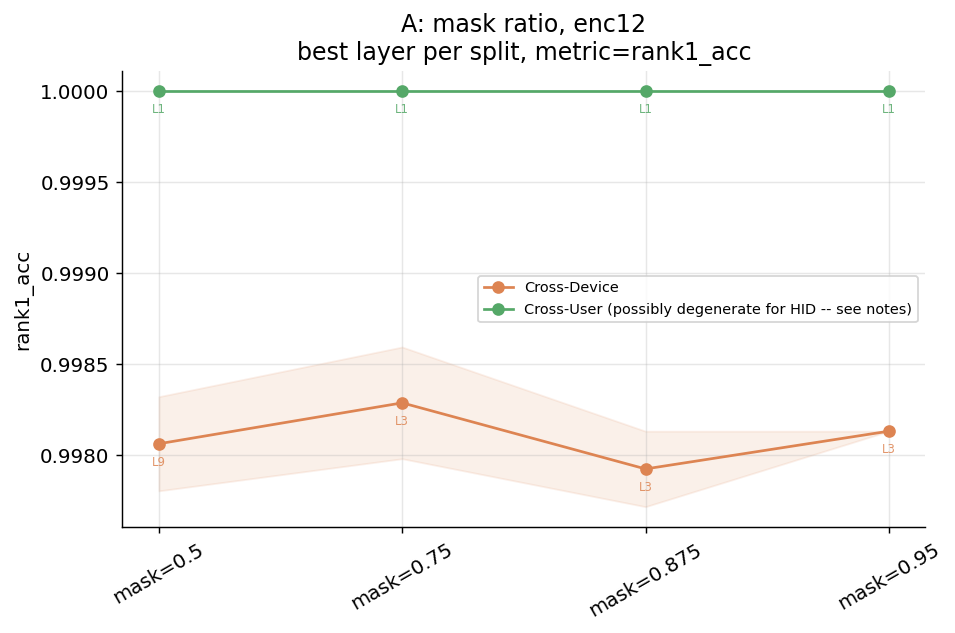

[skip] no data for metric='verification_auc' in 'A: mask ratio, enc12' (check PRIMARY_METRICS matches your real key names)


In [10]:

if a_groups:
    plot_best_layer_by_metric(a_groups, "A: mask ratio, enc12", group_label_fmt="mask={k}", figname_prefix="hid")


## Section B -- Mask strategy, enc6 Ablation (HID)

In [11]:

B_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

b_results = load_matching_results(RESULTS_DIR, B_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not b_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    b_groups = {}
else:
    b_groups = group_by(b_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(b_results)} files across {len(b_groups)} groups: "
          f"{ {k: len(v) for k, v in b_groups.items()} }")
    diagnose_incomplete_runs_hid(b_results, "B")


Found 1 files across 1 groups: {'random': 1}
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_1
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_user' entirely at epoch_50/layer_1
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[B] mae_hid_ep300_mask0.75_strategyrandom_ph29pw25_seed42_enc6_dim128_bs128: MISSING split 'test_cross_device' entirely at epoch_50/layer_3
[B] mae_hid_ep300

In [12]:

if b_groups:
    plot_best_layer_by_metric(b_groups, "B: mask strategy, enc6", group_label_fmt="{k}", figname_prefix="hid")


[skip] no data for metric='closed_set_acc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='rank1_acc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)
[skip] no data for metric='verification_auc' in 'B: mask strategy, enc6' (check PRIMARY_METRICS matches your real key names)


## Section D -- Mask strategy, enc12 Ablation (HID)

In [13]:

D_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}
DEBUG = False

d_results = load_matching_results(RESULTS_DIR, D_FILTERS, debug=DEBUG, task_prefix="mae_hid")
if not d_results:
    print("No matching HID files. Set DEBUG=True above and re-run this cell.")
    d_groups = {}
else:
    d_groups = group_by(d_results, key_fn=lambda r: r["args"]["mask_strategy"])
    print(f"Found {len(d_results)} files across {len(d_groups)} groups: "
          f"{ {k: len(v) for k, v in d_groups.items()} }")
    diagnose_incomplete_runs_hid(d_results, "D")


Found 12 files across 5 groups: {'2d': 2, 'freq': 2, 'mixed': 2, 'random': 4, 'time': 2}
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[D] mae_hid_ep150_mask0.75_strategy2d_ph29pw25_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[D] mae_hid_e

[skip] no data for metric='closed_set_acc' in 'D: mask strategy, enc12' (check PRIMARY_METRICS matches your real key names)

=== D: mask strategy, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
         2d test_cross_device layer_6  0.998754 0.000415        2
         2d   test_cross_user layer_1  1.000000 0.000000        2
       freq test_cross_device layer_3  0.996263 0.000415        2
       freq   test_cross_user layer_1  1.000000 0.000000        2
      mixed test_cross_device layer_9  0.997924 0.000208        2
      mixed   test_cross_user layer_1  1.000000 0.000000        2
     random test_cross_device layer_3  0.998287 0.000307        4
     random   test_cross_user layer_1  1.000000 0.000000        4
       time test_cross_device layer_9  0.998235 0.000104        2
       time   test_cross_user layer_1  1.000000 0.000000        2


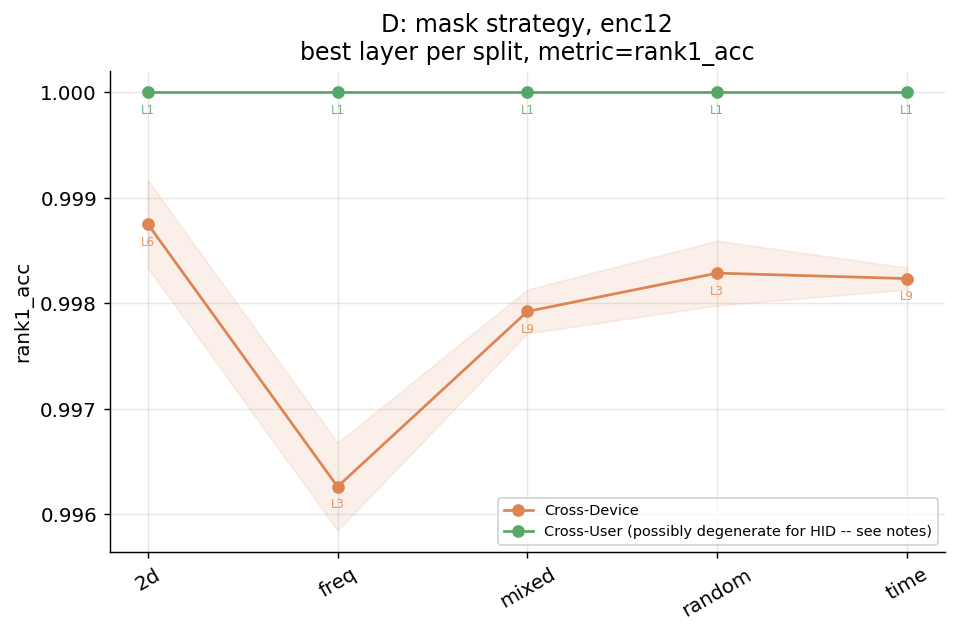

[skip] no data for metric='verification_auc' in 'D: mask strategy, enc12' (check PRIMARY_METRICS matches your real key names)


In [14]:

if d_groups:
    plot_best_layer_by_metric(d_groups, "D: mask strategy, enc12", group_label_fmt="{k}", figname_prefix="hid")


## Section C -- Patch size, enc6 Ablation (HID)

In [15]:

C_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 6,
    "mask_strategy": 'random',
}

c_results_all = load_matching_results(RESULTS_DIR, C_FILTERS, debug=DEBUG, task_prefix="mae_hid")
c_results = [r for r in c_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not c_results:
    print("No matching square-patch HID files. Set DEBUG=True above and re-run.")
    c_groups = {}
else:
    c_groups = group_by(c_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(c_results)} files across {len(c_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in c_groups.items()} }")
    diagnose_incomplete_runs_hid(c_results, "C")


No matching square-patch HID files. Set DEBUG=True above and re-run.


In [16]:

if c_groups:
    plot_best_layer_by_metric(c_groups, "C: patch size, enc6", group_label_fmt="{k}x{k}", figname_prefix="hid")


## Section E -- Patch size, enc12 Ablation (HID)

In [17]:

E_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "mask_strategy": 'random',
}

e_results_all = load_matching_results(RESULTS_DIR, E_FILTERS, debug=DEBUG, task_prefix="mae_hid")
e_results = [r for r in e_results_all
                  if r["args"].get("patch_h") is not None
                  and r["args"].get("patch_h") == r["args"].get("patch_w")]

if not e_results:
    print("No matching square-patch HID files. Set DEBUG=True above and re-run.")
    e_groups = {}
else:
    e_groups = group_by(e_results, key_fn=lambda r: r["args"]["patch_h"])
    print(f"Found {len(e_results)} files across {len(e_groups)} patch sizes: "
          f"{ {k: len(v) for k, v in e_groups.items()} }")
    diagnose_incomplete_runs_hid(e_results, "E")


Found 10 files across 5 patch sizes: {13: 2, 15: 2, 17: 2, 19: 2, 21: 2}
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_device missing metrics: ['closed_set_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_env missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_1/test_cross_user missing ['closed_set_acc', 'verification_auc'] -- note: may be the expected open-set degenerate case, not an error
[E] mae_hid_ep150_mask0.75_strategyrandom_ph13pw13_seed42_enc12_dim128_bs128: epoch_50/layer_3/test_id missing metrics: ['closed_set_acc', 'rank1_acc', 'verification_auc']
[E] mae_h

[skip] no data for metric='closed_set_acc' in 'E: patch size, enc12' (check PRIMARY_METRICS matches your real key names)

=== E: patch size, enc12 -- rank1_acc ===
group_label             split   layer  mean_val  std_val  n_seeds
      13x13 test_cross_device layer_9  0.998754 0.000208        2
      13x13   test_cross_user layer_1  1.000000 0.000000        2
      15x15 test_cross_device layer_9  0.998858 0.000311        2
      15x15   test_cross_user layer_1  1.000000 0.000000        2
      17x17 test_cross_device layer_6  0.998132 0.000830        2
      17x17   test_cross_user layer_1  1.000000 0.000000        2
      19x19 test_cross_device layer_6  0.998339 0.000000        2
      19x19   test_cross_user layer_1  1.000000 0.000000        2
      21x21 test_cross_device layer_3  0.998028 0.000104        2
      21x21   test_cross_user layer_1  1.000000 0.000000        2


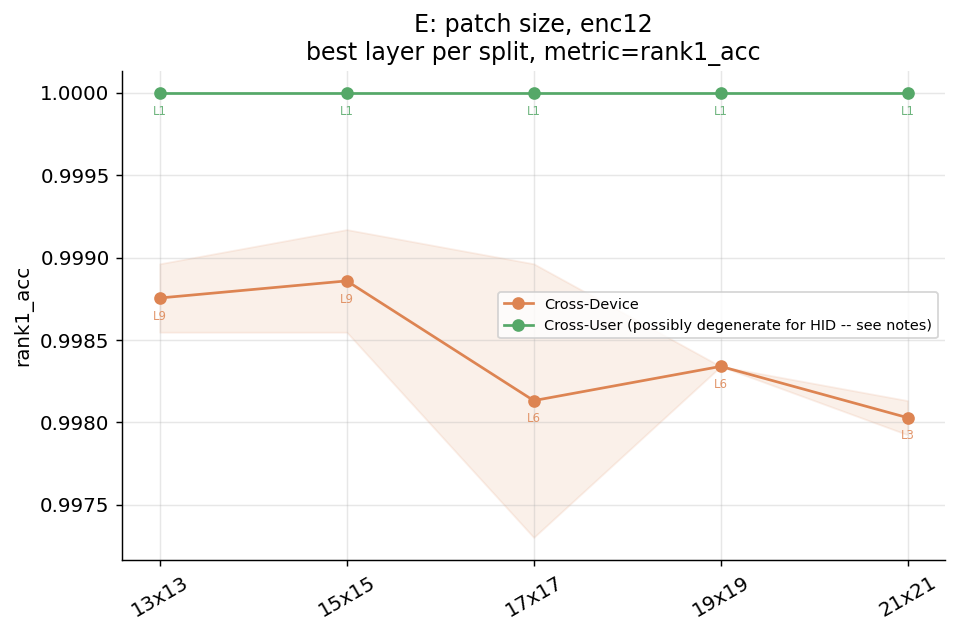

[skip] no data for metric='verification_auc' in 'E: patch size, enc12' (check PRIMARY_METRICS matches your real key names)


In [18]:

if e_groups:
    plot_best_layer_by_metric(e_groups, "E: patch size, enc12", group_label_fmt="{k}x{k}", figname_prefix="hid")


In [19]:
# Diagnostic Cell 1: Directly parse the specific JSON file
import json
from pathlib import Path

target_file = Path("/home/zhuzih19/csi-project/csi-fall-detection/results/mae_hid/mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed43_enc12_dim128_bs128.json")

if target_file.exists():
    try:
        data = json.loads(target_file.read_text())
        print(f"SUCCESS: Loaded {target_file.name}")
        print(f"exp_name: {data.get('exp')}")
        print(f"args keys: {list(data.get('args', {}).keys())}")
        print(f"evals keys: {list(data.get('evals', {}).keys())}")
        if 'args' in data and 'evals' in data:
            print("The file structure is valid.")
    except Exception as e:
        print(f"FAILED to parse JSON: {e}")
else:
    print(f"ERROR: The file does not exist at {target_file}")

SUCCESS: Loaded mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed43_enc12_dim128_bs128.json
exp_name: mae_hid_ep150_mask0.75_strategyfreq_ph29pw25_seed43_enc12_dim128_bs128
args keys: ['epochs', 'mask_ratio', 'encoder_depth', 'encoder_dim', 'decoder_dim', 'batch_size', 'lr', 'eval_layers', 'eval_every', 'mask_strategy', 'patch_h', 'patch_w', 'seed', 'skip_mem_check', 'mem_budget_gb', 'domain_adv_lambda', 'domain_adv_column', 'domain_adv_layer', 'domain_adv_hidden_dim', 'domain_adv_optimizer', 'domain_adv_lr', 'run_attentive_probe', 'attentive_probe_epochs', 'resume_from', 'n_verification_pairs', 'padded_h', 'padded_w', 'num_patches']
evals keys: ['epoch_50', 'epoch_100', 'epoch_150']
The file structure is valid.


In [20]:
# Diagnostic Cell 2: Run the existing loader with debug=True to see the skip reason
# Ensure the function `load_matching_results` and `group_by` are defined in your notebook.
# If not, run the initialization cells first.

DEBUG = True
D_FILTERS = {
    "mask_ratio": 0.75,
    "encoder_depth": 12,
    "patch_h": 29,
    "patch_w": 25,
}

# Re-run the loading cell with debug explicitly turned on
d_results_debug = load_matching_results(
    RESULTS_DIR, 
    D_FILTERS, 
    debug=DEBUG, 
    task_prefix="mae_hid"
)

print(f"Total files matched after debug: {len(d_results_debug)}")
if len(d_results_debug) == 0:
    print("All matching files were skipped. See the [skip] prints above to identify the reason (e.g., key mismatch or type mismatch).")
else:
    print("Files successfully loaded.")

[debug] found 321 .json files under /home/zhuzih19/csi-project/csi-fall-detection/results (recursive)
[skip] best_performance.json: exp='' does not start with task_prefix='mae_hid'
[skip] lstm_FallDetection_config.json: exp='' does not start with task_prefix='mae_hid'
[skip] lstm_FallDetection_results.json: exp='' does not start with task_prefix='mae_hid'
[skip] lstm_FallDetection_summary.json: exp='' does not start with task_prefix='mae_hid'
[skip] supervised_config.json: exp='' does not start with task_prefix='mae_hid'
[skip] best_performance.json: exp='' does not start with task_prefix='mae_hid'
[skip] mlp_FallDetection_config.json: exp='' does not start with task_prefix='mae_hid'
[skip] mlp_FallDetection_results.json: exp='' does not start with task_prefix='mae_hid'
[skip] mlp_FallDetection_summary.json: exp='' does not start with task_prefix='mae_hid'
[skip] supervised_config.json: exp='' does not start with task_prefix='mae_hid'
[skip] best_performance.json: exp='' does not start

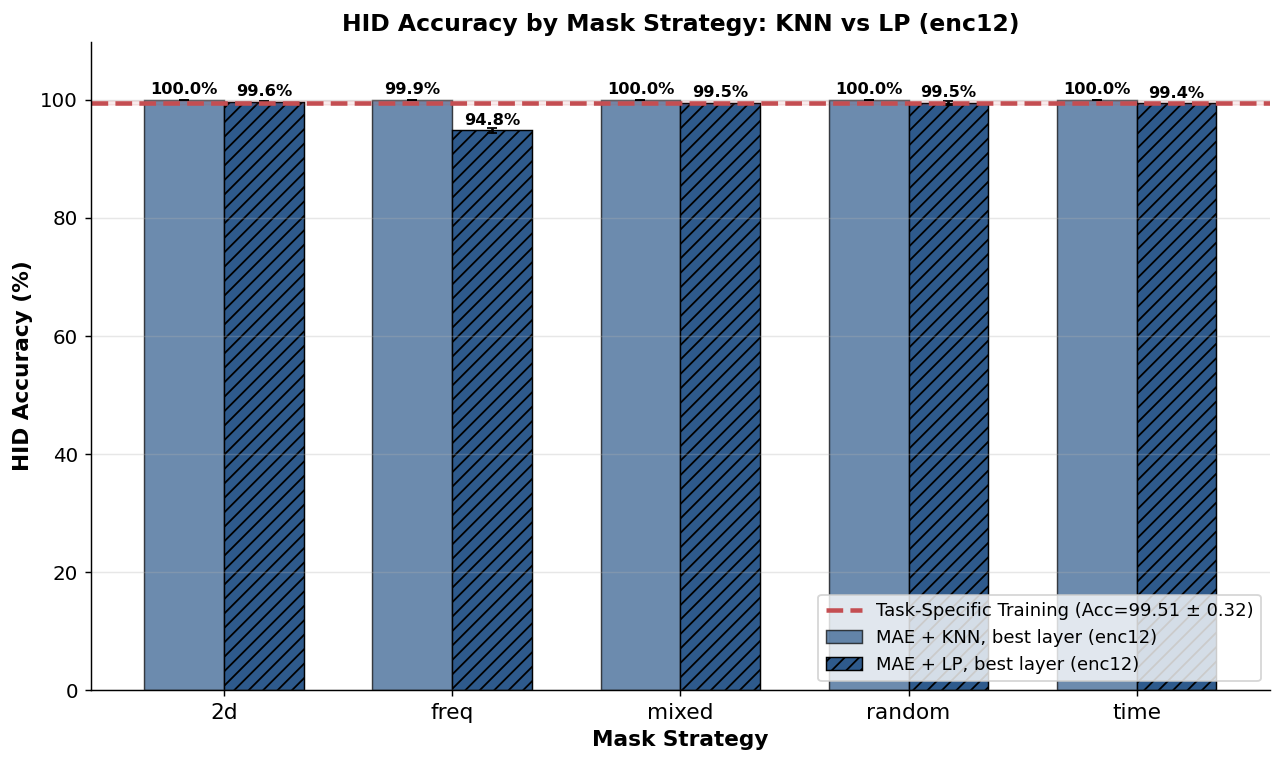

In [21]:
# ============================================================
# COMPARE HID ACCURACY ACROSS MASK STRATEGIES -- ENC12 ONLY
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

BASELINE_ACC = 99.51
BASELINE_STD = 0.32
SPLIT_TO_PLOT = "test_id"
strategy_order = ["2d", "freq", "mixed", "random", "time"]

def get_series(groups, metric_name, split=SPLIT_TO_PLOT):
    means, stds = [], []
    for strat in strategy_order:
        runs = groups.get(strat, [])
        if not runs:
            means.append(np.nan)
            stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

acc_knn, std_knn = get_series(d_groups, "knn_acc")
acc_lp,  std_lp  = get_series(d_groups, "lp_acc")

x = np.arange(len(strategy_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_knn = ax.bar(x - width/2, acc_knn, width, yerr=std_knn, capsize=3,
                  label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                  edgecolor="black", linewidth=0.8)

bars_lp = ax.bar(x + width/2, acc_lp,  width, yerr=std_lp,  capsize=3,
                 label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                 edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars_knn, bars_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(strategy_order, fontsize=12)
ax.set_xlabel("Mask Strategy", fontsize=12, fontweight="bold")
ax.set_ylabel("HID Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HID Accuracy by Mask Strategy: KNN vs LP (enc12)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 10))
plt.tight_layout()
plt.show()

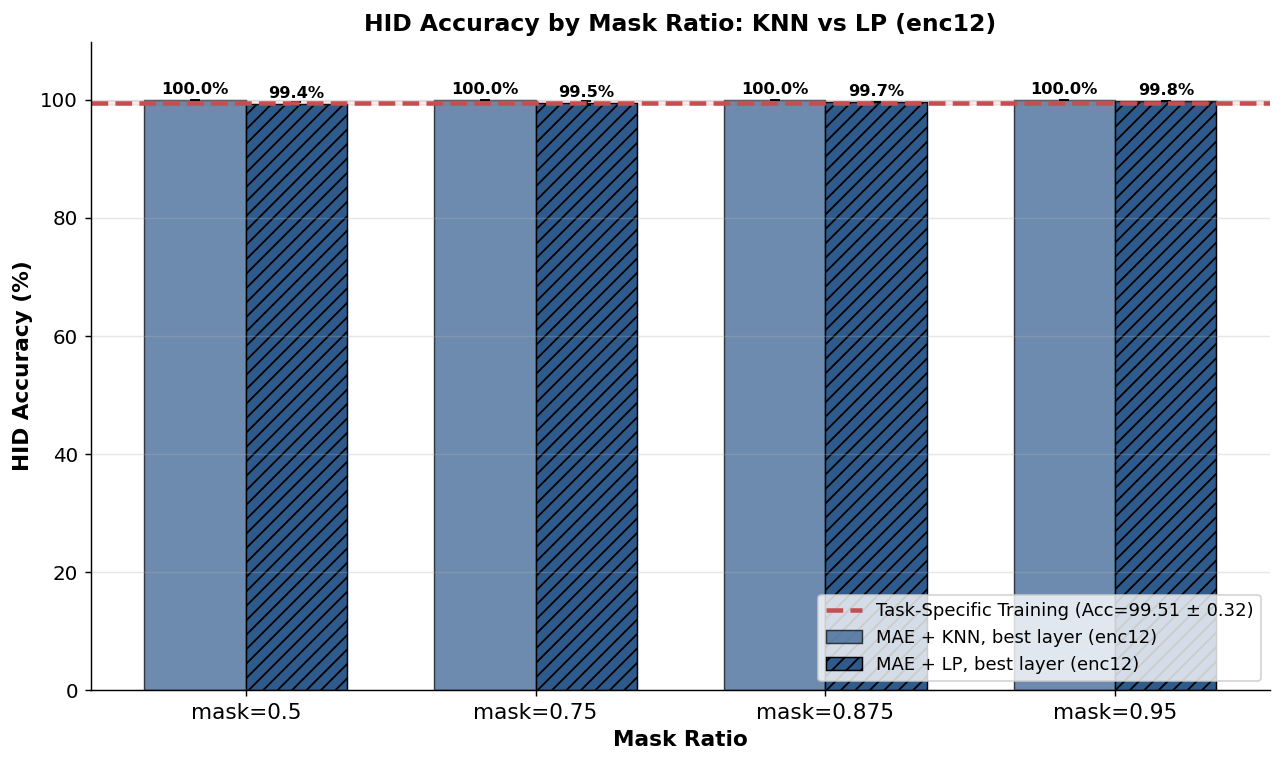

In [22]:
# ============================================================
# COMPARE HID ACCURACY ACROSS MASK RATIOS -- ENC12 ONLY
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

BASELINE_ACC = 99.51
BASELINE_STD = 0.32
SPLIT_TO_PLOT = "test_id"
ratio_order = [0.5, 0.75, 0.875, 0.95]

def get_ratio_series(groups, metric_name, split=SPLIT_TO_PLOT):
    means, stds = [], []
    for ratio in ratio_order:
        runs = groups.get(ratio, [])
        if not runs:
            means.append(np.nan)
            stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

assert 'a_groups' in globals() and a_groups, "Please run Section A's loading cell (enc12) first."

acc_knn, std_knn = get_ratio_series(a_groups, "knn_acc")
acc_lp,  std_lp  = get_ratio_series(a_groups, "lp_acc")

x = np.arange(len(ratio_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_knn = ax.bar(x - width/2, acc_knn, width, yerr=std_knn, capsize=3,
                  label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                  edgecolor="black", linewidth=0.8)

bars_lp = ax.bar(x + width/2, acc_lp,  width, yerr=std_lp,  capsize=3,
                 label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                 edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars_knn, bars_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"mask={r}" for r in ratio_order], fontsize=12)
ax.set_xlabel("Mask Ratio", fontsize=12, fontweight="bold")
ax.set_ylabel("HID Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HID Accuracy by Mask Ratio: KNN vs LP (enc12)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 10))
plt.tight_layout()
plt.show()


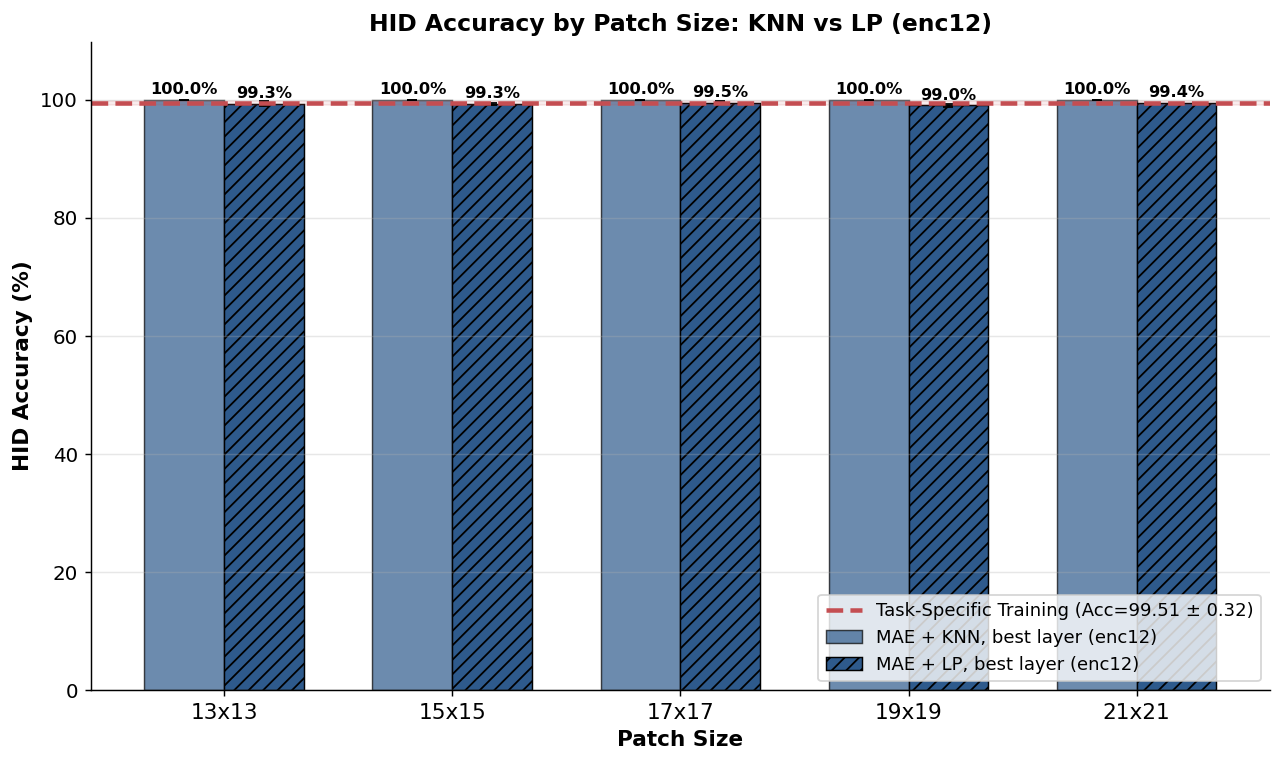

In [23]:
# ============================================================
# COMPARE HID ACCURACY ACROSS PATCH SIZES -- ENC12 ONLY
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

BASELINE_ACC = 99.51
BASELINE_STD = 0.32
SPLIT_TO_PLOT = "test_id"
patch_order = [13, 15, 17, 19, 21]

def get_patch_series(groups, metric_name, split=SPLIT_TO_PLOT):
    means, stds = [], []
    for p_size in patch_order:
        runs = groups.get(p_size, [])
        if not runs:
            means.append(np.nan)
            stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

assert 'e_groups' in globals() and e_groups, "Please run Section E's loading cell (enc12) first."

acc_knn, std_knn = get_patch_series(e_groups, "knn_acc")
acc_lp,  std_lp  = get_patch_series(e_groups, "lp_acc")

x = np.arange(len(patch_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_knn = ax.bar(x - width/2, acc_knn, width, yerr=std_knn, capsize=3,
                  label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
                  edgecolor="black", linewidth=0.8)

bars_lp = ax.bar(x + width/2, acc_lp,  width, yerr=std_lp,  capsize=3,
                 label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
                 edgecolor="black", linewidth=0.8, hatch="///")

ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

for bars in [bars_knn, bars_lp]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{p}x{p}" for p in patch_order], fontsize=12)
ax.set_xlabel("Patch Size", fontsize=12, fontweight="bold")
ax.set_ylabel("HID Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title(f"HID Accuracy by Patch Size: KNN vs LP (enc12)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3, axis="y")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, max(ymax, BASELINE_ACC + BASELINE_STD + 10))
plt.tight_layout()
plt.show()

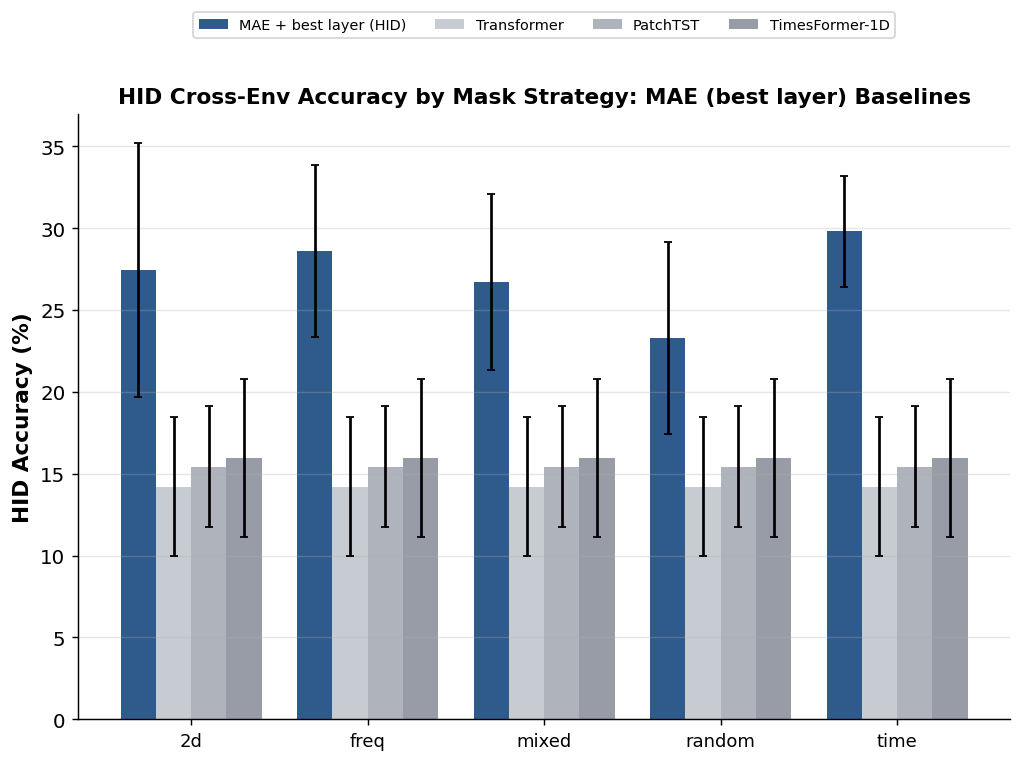

In [24]:
# ============================================================
# HID CROSS-ENV ACCURACY BY MASK STRATEGY vs. TABLE 13 BASELINES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Table 13 (HumanIdentification) -- Acc_cross_env column only
TABLE13_BASELINE = {
    "transformer":   {"test_cross_env": {"acc": (0.1421, 0.0423)}},
    "patchtst":      {"test_cross_env": {"acc": (0.1544, 0.0369)}},
    "timesformer1d": {"test_cross_env": {"acc": (0.1595, 0.0483)}},
}

strategy_order = ["2d", "freq", "mixed", "random", "time"]
SPLIT_TO_PLOT = "test_cross_env"

assert 'd_groups' in globals() and d_groups, "Please run Section D loading cell (enc12) first."

# 1. Extract MAE best-layer data from actual d_groups using best_layer_for_metric
def extract_mae_series(groups, metric_name, split=SPLIT_TO_PLOT):
    means, stds = [], []
    for strat in strategy_order:
        runs = groups.get(strat, [])
        if not runs:
            means.append(np.nan)
            stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

# Since KNN generally performs better on Cross-Env, we use KNN as the "best layer" MAE result
acc_mae, std_mae = extract_mae_series(d_groups, "knn_acc", split=SPLIT_TO_PLOT)

# 2. Plotting with the requested multi-bar layout
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(strategy_order))
n_bars = 4  # 1 for MAE-HID, 3 for baselines
width = 0.8 / n_bars

mae_color = "#2E5A8C"
baseline_colors = {"transformer": "#B0B7C0", "patchtst": "#8C93A0", "timesformer1d": "#6B7280"}
baseline_display = {"transformer": "Transformer", "patchtst": "PatchTST", "timesformer1d": "TimesFormer-1D"}

# Bar 1: MAE-HID (best layer)
b1 = ax.bar(x + (0 - (n_bars-1)/2)*width, acc_mae, width, yerr=std_mae, capsize=2,
            color=mae_color, label="MAE + best layer (HID)")

# Bars 2-4: Baseline models (broadcast across every x-position as reference)
for i, model_key in enumerate(["transformer", "patchtst", "timesformer1d"]):
    acc_mean, acc_std = TABLE13_BASELINE[model_key]["test_cross_env"]["acc"]
    vals = np.full(len(strategy_order), acc_mean * 100)
    stds = np.full(len(strategy_order), acc_std * 100)
    ax.bar(x + (1 + i - (n_bars-1)/2)*width, vals, width, yerr=stds, capsize=2,
           color=baseline_colors[model_key], alpha=0.7, label=baseline_display[model_key])

ax.set_xticks(x)
ax.set_xticklabels(strategy_order, fontsize=10)
ax.set_ylabel("HID Accuracy (%)", fontsize=12, fontweight="bold")
ax.set_title("HID Cross-Env Accuracy by Mask Strategy: MAE (best layer) Baselines",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, axis="y")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

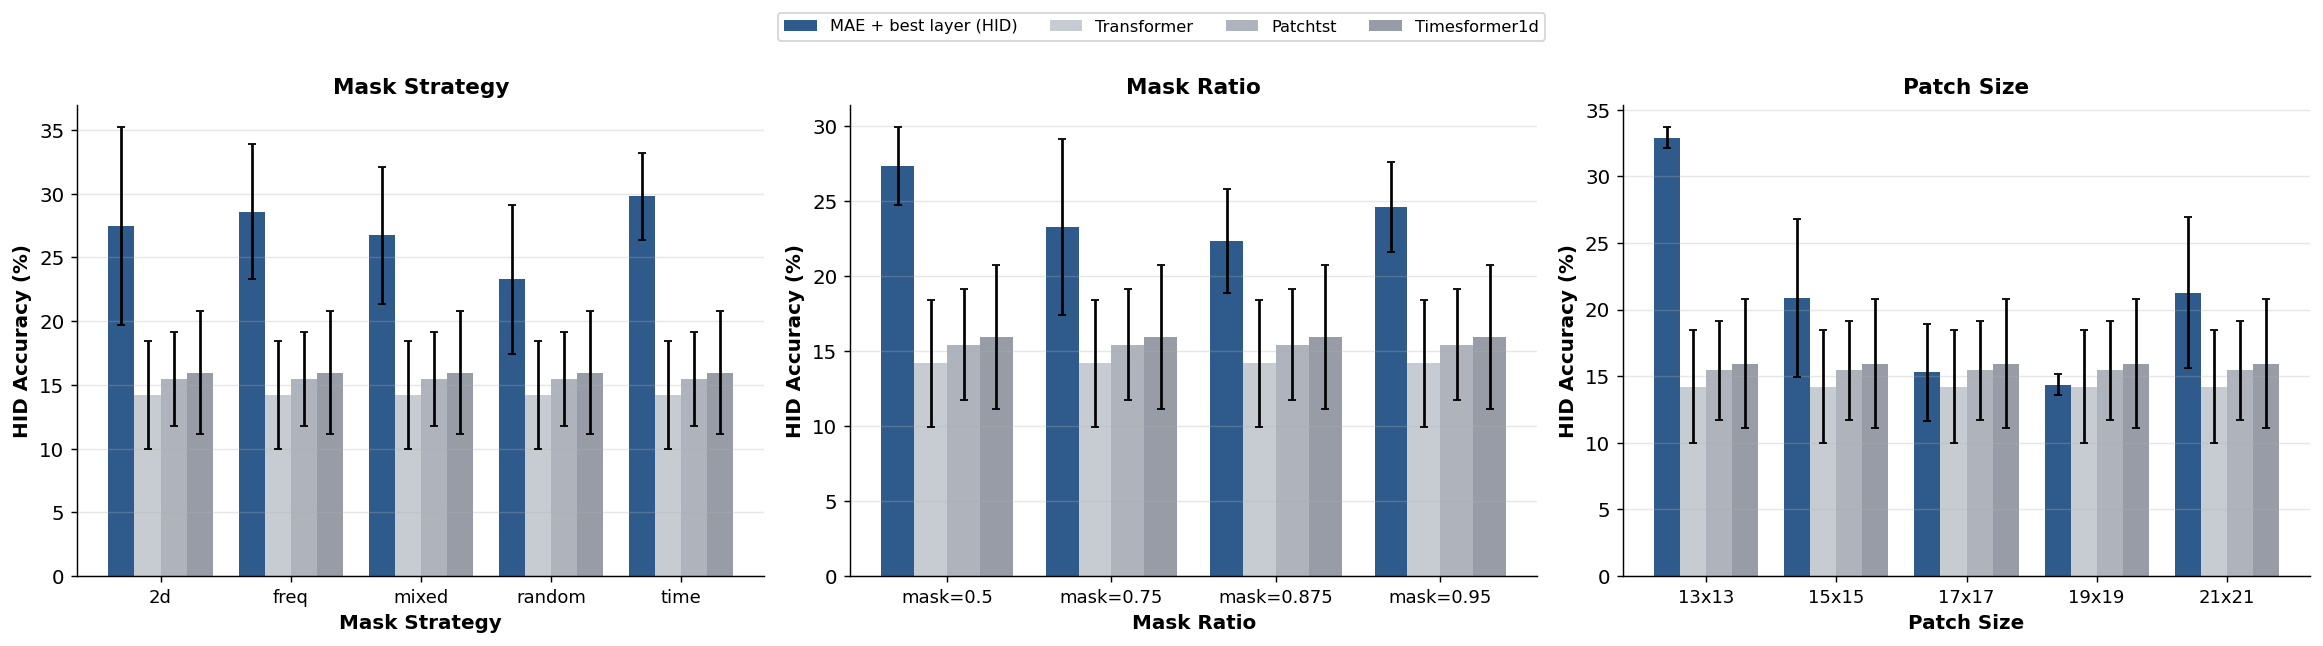

In [25]:
# ============================================================
# HID THREE-PANEL PLOT (UNIFIED STYLE: MAE Blue vs 3 Gray Baselines)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Table 13 Baselines (Acc_cross_env column only)
TABLE13_BASELINE = {
    "transformer":   {"acc": (0.1421, 0.0423)},
    "patchtst":      {"acc": (0.1544, 0.0369)},
    "timesformer1d": {"acc": (0.1595, 0.0483)},
}

strategy_order = ["2d", "freq", "mixed", "random", "time"]
ratio_order = [0.5, 0.75, 0.875, 0.95]
patch_order = [13, 15, 17, 19, 21]

assert 'd_groups' in globals() and d_groups, "Missing d_groups (Mask Strategy)"
assert 'a_groups' in globals() and a_groups, "Missing a_groups (Mask Ratio)"
assert 'e_groups' in globals() and e_groups, "Missing e_groups (Patch Size)"

def get_ood_series(groups, order, metric_name, split="test_cross_env"):
    means, stds = [], []
    for key in order:
        runs = groups.get(key, [])
        if not runs:
            means.append(np.nan); stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan); stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

def plot_unified_panel(ax, x_labels, mae_means, mae_stds, title, x_label):
    x = np.arange(len(x_labels))
    n_bars = 4
    width = 0.8 / n_bars
    mae_color = "#2E5A8C"
    baseline_colors = {"transformer": "#B0B7C0", "patchtst": "#8C93A0", "timesformer1d": "#6B7280"}
    
    # MAE Bar
    ax.bar(x + (0 - (n_bars-1)/2)*width, mae_means, width, yerr=mae_stds, capsize=2,
           color=mae_color, label="MAE + best layer (HID)")
    
    # Baselines (with standard deviations)
    for i, model_key in enumerate(["transformer", "patchtst", "timesformer1d"]):
        acc_mean, acc_std = TABLE13_BASELINE[model_key]["acc"]
        vals = np.full(len(x_labels), acc_mean * 100)
        stds = np.full(len(x_labels), acc_std * 100)
        ax.bar(x + (1 + i - (n_bars-1)/2)*width, vals, width, yerr=stds, capsize=2,
               color=baseline_colors[model_key], alpha=0.7, label=model_key.capitalize())
    
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel(x_label, fontsize=11, fontweight="bold")
    ax.set_ylabel("HID Accuracy (%)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
    return ax

# Fetch data for all panels (all on test_cross_env)
mae_strategy, std_strategy = get_ood_series(d_groups, strategy_order, "knn_acc")
mae_ratio, std_ratio = get_ood_series(a_groups, ratio_order, "knn_acc")
mae_patch, std_patch = get_ood_series(e_groups, patch_order, "knn_acc")

# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot each panel
plot_unified_panel(axes[0], strategy_order, mae_strategy, std_strategy, 
                   "Mask Strategy", "Mask Strategy")

plot_unified_panel(axes[1], [f"mask={r}" for r in ratio_order], mae_ratio, std_ratio, 
                   "Mask Ratio", "Mask Ratio")

plot_unified_panel(axes[2], [f"{p}x{p}" for p in patch_order], mae_patch, std_patch, 
                   "Patch Size", "Patch Size")

# Common legend (manually placed on the rightmost subplot, sharing the others)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
fig.savefig(FIG_DIR / "hid_id_3panel_combined.png", dpi=300, bbox_inches="tight")

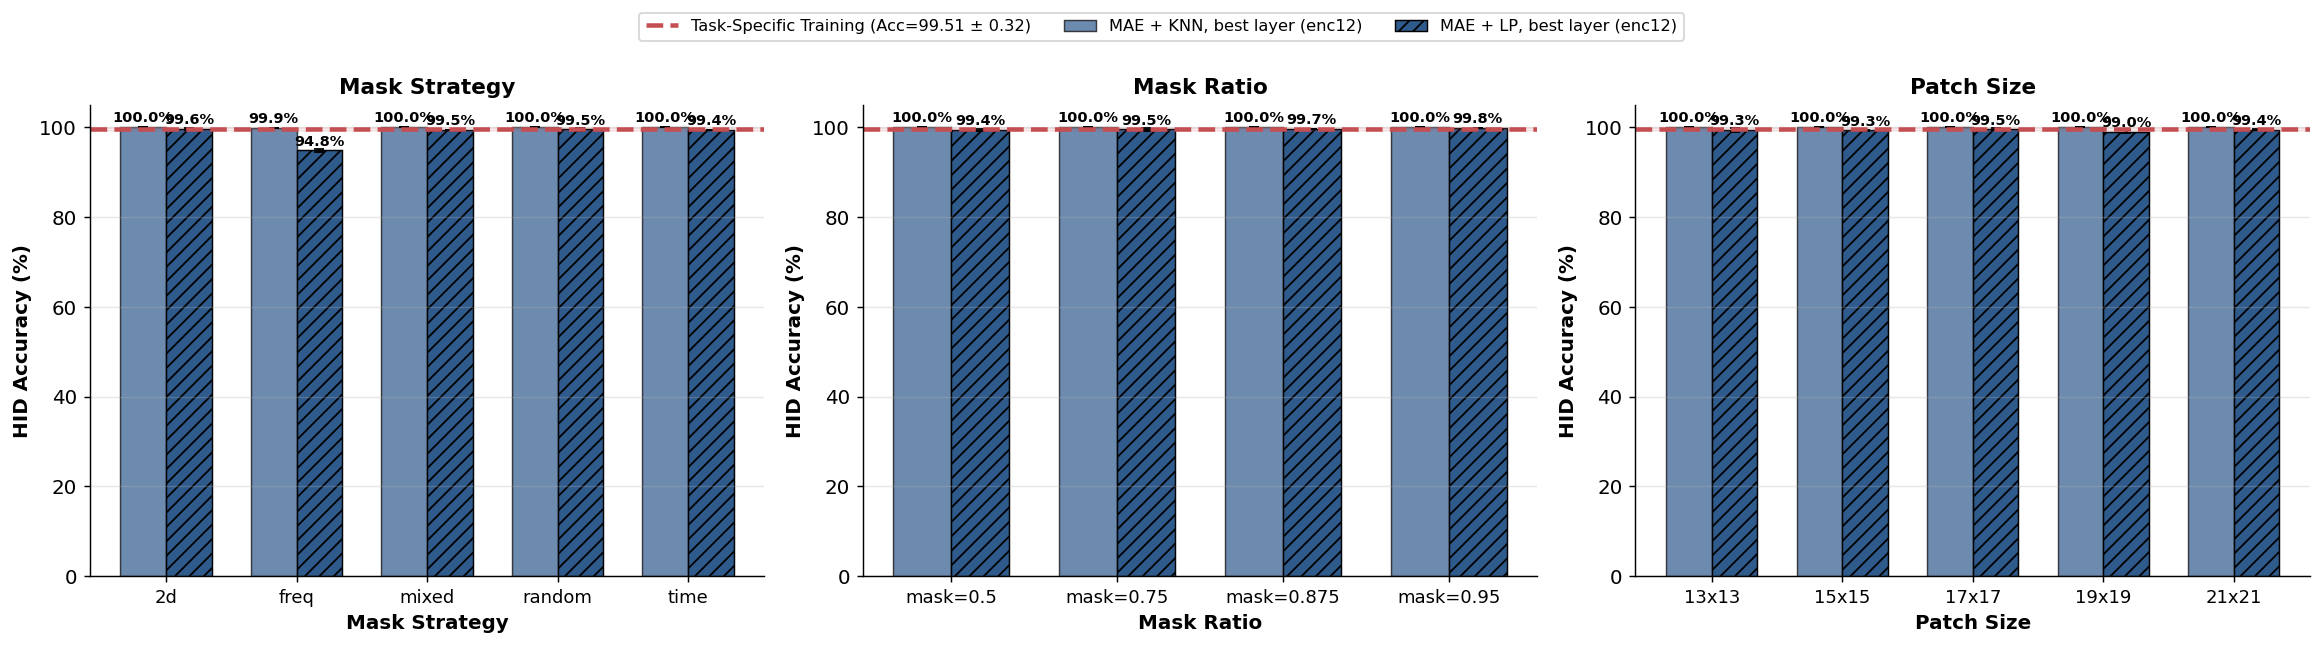

In [26]:
# ============================================================
# HID THREE-PANEL PLOT (ID SETTING) - FIXED
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

BASELINE_ACC = 99.51
BASELINE_STD = 0.32

strategy_order = ["2d", "freq", "mixed", "random", "time"]
ratio_order = [0.5, 0.75, 0.875, 0.95]
patch_order = [13, 15, 17, 19, 21]

assert 'd_groups' in globals() and d_groups, "Missing d_groups (Mask Strategy)"
assert 'a_groups' in globals() and a_groups, "Missing a_groups (Mask Ratio)"
assert 'e_groups' in globals() and e_groups, "Missing e_groups (Patch Size)"

def get_id_series(groups, order, metric_name, split="test_id"):
    means, stds = [], []
    for key in order:
        runs = groups.get(key, [])
        if not runs:
            means.append(np.nan); stds.append(np.nan)
            continue
        best = best_layer_for_metric(runs, metric=metric_name, splits=[split])
        b = best.get(split)
        if b is None:
            means.append(np.nan); stds.append(np.nan)
        else:
            means.append(b["mean_val"] * 100)
            stds.append(b["std_val"] * 100)
    return np.array(means), np.array(stds)

def plot_id_panel(ax, x_labels, knn_means, knn_stds, lp_means, lp_stds, title, x_label):
    x = np.arange(len(x_labels))
    width = 0.35

    bar_knn = ax.bar(x - width/2, knn_means, width, yerr=knn_stds, capsize=3,
           label="MAE + KNN, best layer (enc12)", color="#2E5A8C", alpha=0.7,
           edgecolor="black", linewidth=0.8)

    bar_lp = ax.bar(x + width/2, lp_means,  width, yerr=lp_stds,  capsize=3,
           label="MAE + LP, best layer (enc12)",  color="#2E5A8C", alpha=1.0,
           edgecolor="black", linewidth=0.8, hatch="///")

    ax.axhline(BASELINE_ACC, color="#C44E52", linestyle="--", linewidth=2.5,
               label=f"Task-Specific Training (Acc={BASELINE_ACC:.2f} ± {BASELINE_STD:.2f})")
    ax.axhspan(BASELINE_ACC - BASELINE_STD, BASELINE_ACC + BASELINE_STD, color="#C44E52", alpha=0.10)

    for bars in [bar_knn, bar_lp]:
        if bars is not None:
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h):
                    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%",
                            ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel(x_label, fontsize=11, fontweight="bold")
    ax.set_ylabel("HID Accuracy (%)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3, axis="y")
    return ax

knn_strat, std_knn_strat = get_id_series(d_groups, strategy_order, "knn_acc")
lp_strat,  std_lp_strat  = get_id_series(d_groups, strategy_order, "lp_acc")

knn_ratio, std_knn_ratio = get_id_series(a_groups, ratio_order, "knn_acc")
lp_ratio,  std_lp_ratio  = get_id_series(a_groups, ratio_order, "lp_acc")

knn_patch, std_knn_patch = get_id_series(e_groups, patch_order, "knn_acc")
lp_patch,  std_lp_patch  = get_id_series(e_groups, patch_order, "lp_acc")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_id_panel(axes[0], strategy_order, knn_strat, std_knn_strat, lp_strat, std_lp_strat,
              "Mask Strategy", "Mask Strategy")

plot_id_panel(axes[1], [f"mask={r}" for r in ratio_order], knn_ratio, std_knn_ratio, lp_ratio, std_lp_ratio,
              "Mask Ratio", "Mask Ratio")

plot_id_panel(axes[2], [f"{p}x{p}" for p in patch_order], knn_patch, std_knn_patch, lp_patch, std_lp_patch,
              "Patch Size", "Patch Size")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.0), fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

fig.savefig(FIG_DIR / "hid_ood_3panel_combined.png", dpi=300, bbox_inches="tight")

In [27]:
# =====================================================================
# SECTION: HID Open-Set Analysis (3-Panel Combined Figure)
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

OPEN_SET_METRIC = 'verif_auc'

def build_openset_table(groups, split, metric, group_label_fmt="{k}"):
    rows = []
    for key, runs in sorted(groups.items(), key=lambda kv: (isinstance(kv[0], str), kv[0])):
        vals = []
        for r in runs:
            final_ckpt = get_openset_checkpoints(r)[-1]
            layers = get_openset_layers(r, final_ckpt)
            best_val = None
            for layer_key in layers:
                d = r['evals'][final_ckpt][layer_key].get(split)
                if not d or d.get(metric) is None:
                    continue
                val = d[metric]
                if best_val is None or val > best_val:
                    best_val = val
            if best_val is not None:
                vals.append(best_val)
        if not vals:
            rows.append({'group': group_label_fmt.format(k=key), 'mean': None, 'std': None, 'n': 0})
            continue
        rows.append({
            'group': group_label_fmt.format(k=key),
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)) if len(vals) > 1 else 0.0,
            'n': len(vals),
        })
    return pd.DataFrame(rows)

def plot_openset_panel(ax, groups, axis_title, metric=OPEN_SET_METRIC):
    df = build_openset_table(groups, 'test_cross_device', metric)
    df_valid = df[df['mean'].notna()]
    if df_valid.empty:
        ax.text(0.5, 0.5, "No Valid Data", ha='center', va='center')
        ax.set_title(axis_title)
        return

    x = np.arange(len(df_valid))
    bars = ax.bar(x, df_valid['mean'], yerr=df_valid['std'], capsize=4,
                  color='#0891B2', alpha=0.85)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in df_valid['mean']],
                 fontsize=8, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(df_valid['group'])
    ax.set_ylabel("Verif AUC")
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance (AUC=0.5)')
    ax.grid(alpha=0.3, axis='y')
    ax.set_title(f"test_cross_device Verif AUC by {axis_title}", fontsize=10)
    ax.legend(fontsize=7, loc='lower right')

# --- Check required groups ---
missing = []
if 'ratio_groups_os' not in locals() or not ratio_groups_os: missing.append("Mask Ratio")
if 'strategy_groups_os' not in locals() or not strategy_groups_os: missing.append("Mask Strategy")
if 'patch_groups_os' not in locals() or not patch_groups_os: missing.append("Patch Size")

if missing:
    print(f"Warning: Missing data groups for: {', '.join(missing)}. Re-run the loading cells above.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    plot_openset_panel(axes[0], ratio_groups_os, "Mask Ratio")
    plot_openset_panel(axes[1], strategy_groups_os, "Mask Strategy")
    plot_openset_panel(axes[2], patch_groups_os, "Patch Size")

    fig.suptitle("HID Cross-Device Open-Set Verification AUC (Per-Run Best Layer, verif_auc only)", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



In [28]:
# =====================================================================
# SECTION: HID Open-Set Analysis (3-Panel Combined Figure + Cross-User Table)
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

OPEN_SET_METRIC = 'verif_auc'

def build_openset_table(groups, split, metric, group_label_fmt="{k}"):
    rows = []
    for key, runs in sorted(groups.items(), key=lambda kv: (isinstance(kv[0], str), kv[0])):
        vals = []
        for r in runs:
            final_ckpt = get_openset_checkpoints(r)[-1]
            layers = get_openset_layers(r, final_ckpt)
            best_val = None
            for layer_key in layers:
                d = r['evals'][final_ckpt][layer_key].get(split)
                if not d or d.get(metric) is None:
                    continue
                val = d[metric]
                if best_val is None or val > best_val:
                    best_val = val
            if best_val is not None:
                vals.append(best_val)
        if not vals:
            rows.append({'group': group_label_fmt.format(k=key), 'mean': None, 'std': None, 'n': 0})
            continue
        rows.append({
            'group': group_label_fmt.format(k=key),
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)) if len(vals) > 1 else 0.0,
            'n': len(vals),
        })
    return pd.DataFrame(rows)

def plot_openset_panel(ax, groups, axis_title, metric=OPEN_SET_METRIC):
    df = build_openset_table(groups, 'test_cross_device', metric)
    df_valid = df[df['mean'].notna()]
    if df_valid.empty:
        ax.text(0.5, 0.5, "No Valid Data", ha='center', va='center')
        ax.set_title(axis_title)
        return

    x = np.arange(len(df_valid))
    bars = ax.bar(x, df_valid['mean'], yerr=df_valid['std'], capsize=4,
                  color='#0891B2', alpha=0.85)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in df_valid['mean']],
                 fontsize=8, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(df_valid['group'])
    ax.set_ylabel("Verif AUC")
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance (AUC=0.5)')
    ax.grid(alpha=0.3, axis='y')
    ax.set_title(f"Cross-Device Verif AUC by {axis_title}", fontsize=10)
    ax.legend(fontsize=7, loc='lower right')

# Helper to get Cross-User data (Rank1 is always 100% due to single identity)
def get_cross_user_data(groups):
    data = []
    for key, runs in sorted(groups.items(), key=lambda kv: (isinstance(kv[0], str), kv[0])):
        group_label = str(key)
        n_identities = None
        for r in runs:
            final_ckpt = get_openset_checkpoints(r)[-1]
            layers = get_openset_layers(r, final_ckpt)
            for layer_key in layers:
                d = r['evals'][final_ckpt][layer_key].get('test_cross_user')
                if d and d.get('n_identities') is not None:
                    n_identities = d.get('n_identities')
                    break
            if n_identities is not None:
                break
        data.append({
            "Config": group_label,
            "Cross-User Rank-1 Acc": "100.0%",
            "Identities": n_identities if n_identities is not None else "N/A"
        })
    return pd.DataFrame(data)

# ==========================================
# Generate the Figure
# ==========================================
missing = []
if 'ratio_groups_os' not in locals() or not ratio_groups_os: missing.append("Mask Ratio")
if 'strategy_groups_os' not in locals() or not strategy_groups_os: missing.append("Mask Strategy")
if 'patch_groups_os' not in locals() or not patch_groups_os: missing.append("Patch Size")

if missing:
    print(f"Warning: Missing data groups for: {', '.join(missing)}. Re-run the loading cells above.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    plot_openset_panel(axes[0], ratio_groups_os, "Mask Ratio")
    plot_openset_panel(axes[1], strategy_groups_os, "Mask Strategy")
    plot_openset_panel(axes[2], patch_groups_os, "Patch Size")

    fig.suptitle("HID Cross-Device Open-Set Verification AUC", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Print Cross-User summary table below the plot
    # ==========================================
    print("\n" + "="*80)
    print("SUMMARY: Cross-User Open-Set Performance (Trivial single-identity split)")
    print("="*80)
    
    df_cross_user_all = pd.concat([
        get_cross_user_data(ratio_groups_os),
        get_cross_user_data(strategy_groups_os),
        get_cross_user_data(patch_groups_os)
    ], ignore_index=True)
    
    print(df_cross_user_all.to_string(index=False))
    print("="*80)
    print("Note: Cross-User split contains only 1 novel identity (U02).")
    print("Rank-1 retrieval is trivially 100%, and VerifAUC/EER are undefined.")

    fig.savefig(FIG_DIR / "hid_openset_3panel_combined.png", dpi=300, bbox_inches="tight")

In [40]:
def plot_ood_probes_merged(specs, probes=("knn_acc", "lp_acc", "mlp_acc"),
                           ood_split="test_cross_env",
                           ylim=(0.05, 0.45),
                           figname_prefix="hid", figname=None,
                           save=True):
    """
    specs: list of (groups, column_title, group_label_fmt) tuples.
           每个 tuple 一列, 通常 3 个 (ratio / strategy / patch)。
    行 = probe, 列 = ablation axis, 全部 test_cross_env, 共享 y 轴。
    """
    n_rows = len(probes)
    n_cols = len(specs)
    probe_label = {"knn_acc": "KNN", "lp_acc": "LP", "mlp_acc": "MLP"}

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.4 * n_cols, 3.1 * n_rows),
                             sharex=True, sharey=True, squeeze=False)

    cmap = plt.get_cmap("tab10")

    for j, (groups, col_title, glfmt) in enumerate(specs):
        for i, probe in enumerate(probes):
            ax = axes[i][j]
            curves = collect_layer_curves(groups, ood_split, probe)
            if curves:
                for k, gkey in enumerate(sorted(curves.keys(), key=str)):
                    c = curves[gkey]
                    color = cmap(k % 10)
                    # per-seed 散点
                    for li, x_layer in enumerate(c["layers"]):
                        ys = c["per_seed"][li]
                        ax.scatter([x_layer] * len(ys), ys,
                                   s=10, color=color, alpha=0.30,
                                   edgecolor="none", zorder=3)
                    # 均值折线
                    ax.plot(c["layers"], c["mean"],
                            marker="o", markersize=4, linewidth=1.4,
                            color=color, label=glfmt.format(k=gkey),
                            alpha=0.95, zorder=4)

            ax.set_ylim(*ylim)
            ax.ticklabel_format(axis="y", style="plain", useOffset=False)
            ax.grid(alpha=0.3)

            # 第一行: 列标题 + 图例
            if i == 0:
                ax.set_title(col_title, fontsize=11)
                ax.legend(fontsize=7, loc="best", framealpha=0.9)
            # 第一列: probe 作为 y 轴标签
            if j == 0:
                ax.set_ylabel(f"{probe_label.get(probe, probe)}\naccuracy",
                              fontsize=10)
            # 最后一行: x 轴标签
            if i == n_rows - 1:
                ax.set_xlabel("encoder layer")

    fig.suptitle(
        f"Cross-environment (test_cross_env) probe accuracy across encoder depth\n"
        f"rows = probe, columns = ablation axis; shared y-axis "
        f"[{ylim[0]}, {ylim[1]}]; points = per-seed, lines = mean",
        fontsize=12, y=1.00,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if save:
        fname = figname or f"{figname_prefix}_ood_probes_merged.png"
        fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

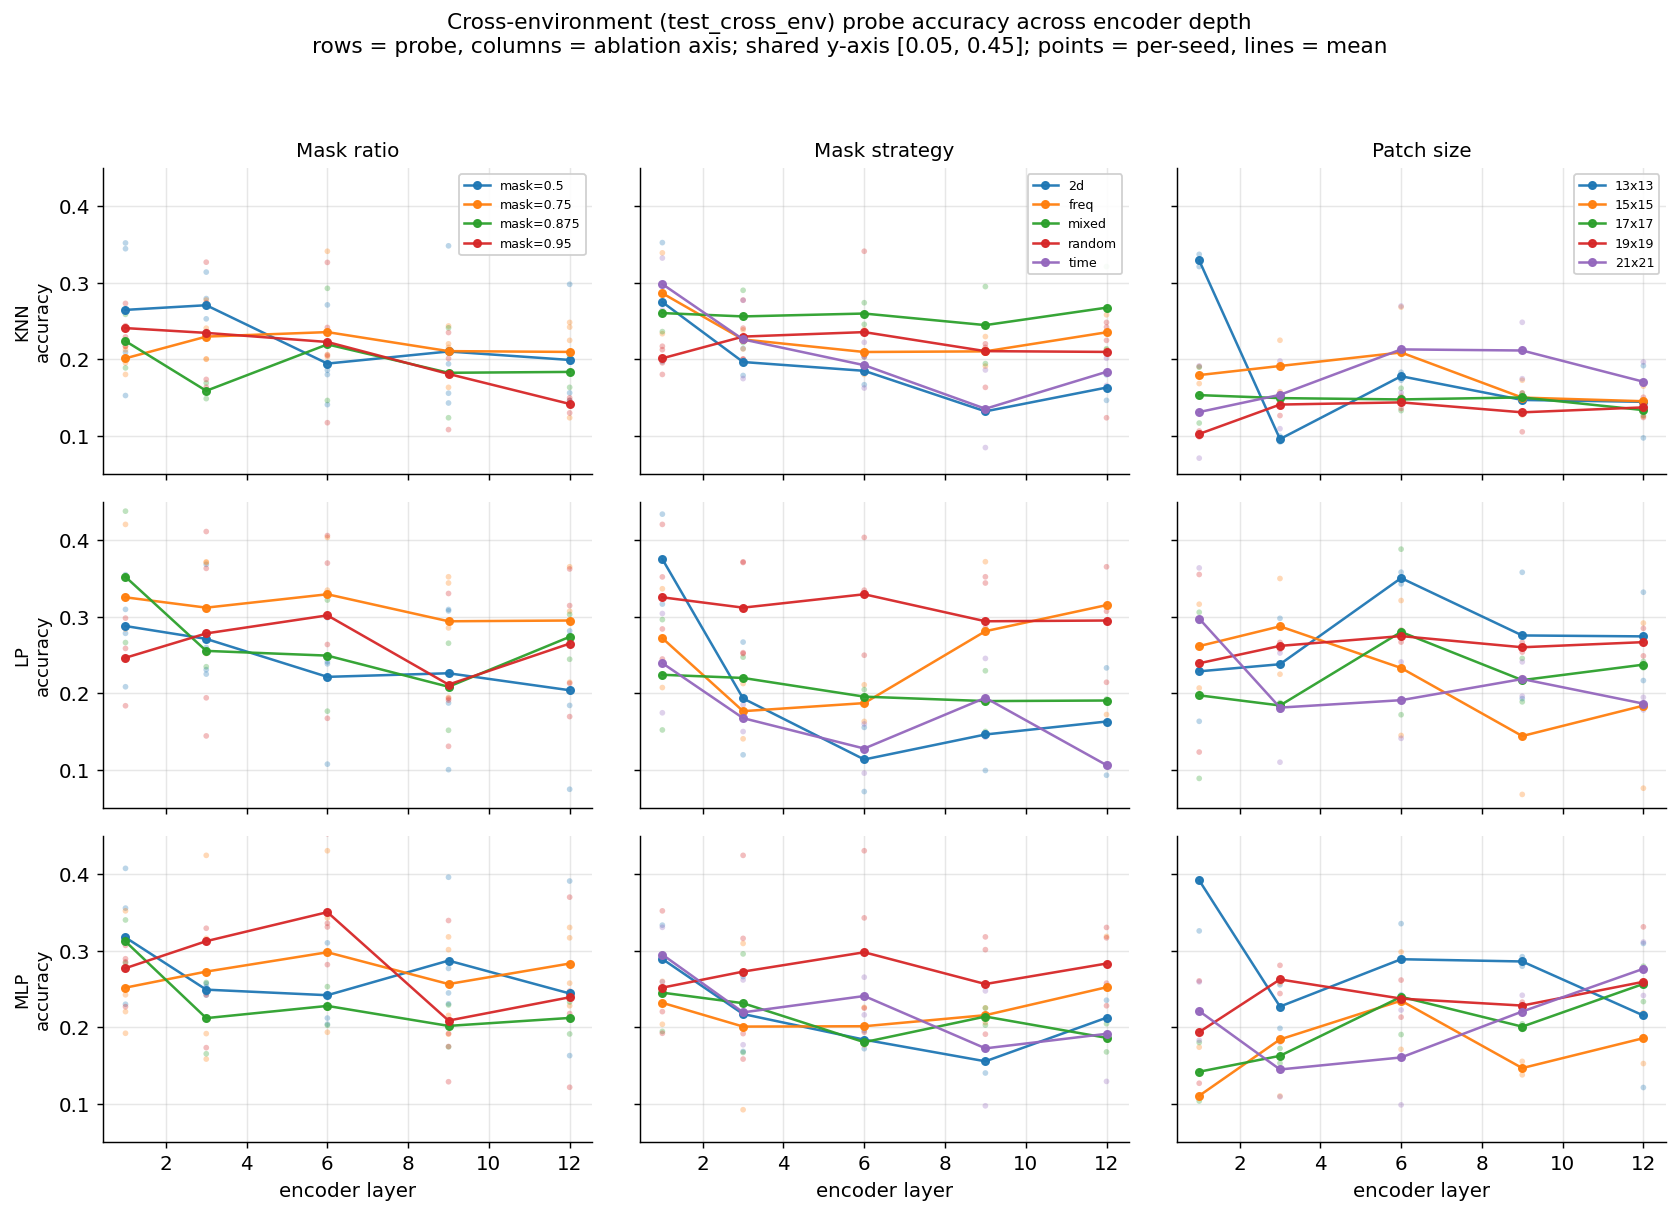

In [41]:
specs = []
if a_groups:
    specs.append((a_groups, "Mask ratio", "mask={k}"))
if d_groups:
    specs.append((d_groups, "Mask strategy", "{k}"))
if e_groups:
    specs.append((e_groups, "Patch size", "{k}x{k}"))

if specs:
    plot_ood_probes_merged(specs, ylim=(0.05, 0.45))

In [36]:
def plot_probe_grid_fixed_ylim(groups, axis_title, group_label_fmt="{k}",
                               probes=("knn_acc", "lp_acc", "mlp_acc"),
                               id_split="test_id", ood_split="test_cross_env",
                               id_ylim=(0.80, 1.02), ood_ylim=(0.05, 0.45),
                               figname_prefix="hid", save=True):
    probe_label = {"knn_acc": "KNN", "lp_acc": "LP", "mlp_acc": "MLP"}
    fig, axes = plt.subplots(len(probes), 2,
                             figsize=(11, 3.4 * len(probes)),
                             squeeze=False, sharex=True)
    cmap = plt.get_cmap("tab10")

    for i, probe in enumerate(probes):
        for j, (split, ylim) in enumerate([(id_split, id_ylim),
                                            (ood_split, ood_ylim)]):
            ax = axes[i][j]
            curves = collect_layer_curves(groups, split, probe)
            if curves:
                for k, gkey in enumerate(sorted(curves.keys(), key=str)):
                    c = curves[gkey]
                    ax.plot(c["layers"], c["mean"],
                            marker="o", markersize=4, linewidth=1.3,
                            label=group_label_fmt.format(k=gkey),
                            color=cmap(k % 10), alpha=0.85)
            ax.set_ylim(*ylim)
            ax.ticklabel_format(axis="y", style="plain", useOffset=False)
            ax.grid(alpha=0.3)
            ax.set_title(f"{probe_label[probe]} -- {split}", fontsize=10)
            if j == 0:
                ax.set_ylabel("accuracy")
            if i == len(probes) - 1:
                ax.set_xlabel("encoder layer")
            if i == 0 and j == 1:
                ax.legend(fontsize=7, loc="best", framealpha=0.9)

    fig.suptitle(f"{axis_title}  --  probe comparison with fixed y-axis per split\n"
                 f"(ID ylim {id_ylim}, OOD ylim {ood_ylim}; no auto-tightening)",
                 fontsize=11, y=1.0)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    if save:
        safe = axis_title.split(":")[0].strip().replace(" ", "_")
        fig.savefig(FIG_DIR / f"{figname_prefix}_{safe}_probe_grid_fixed.png",
                    dpi=150, bbox_inches="tight")
    plt.show()

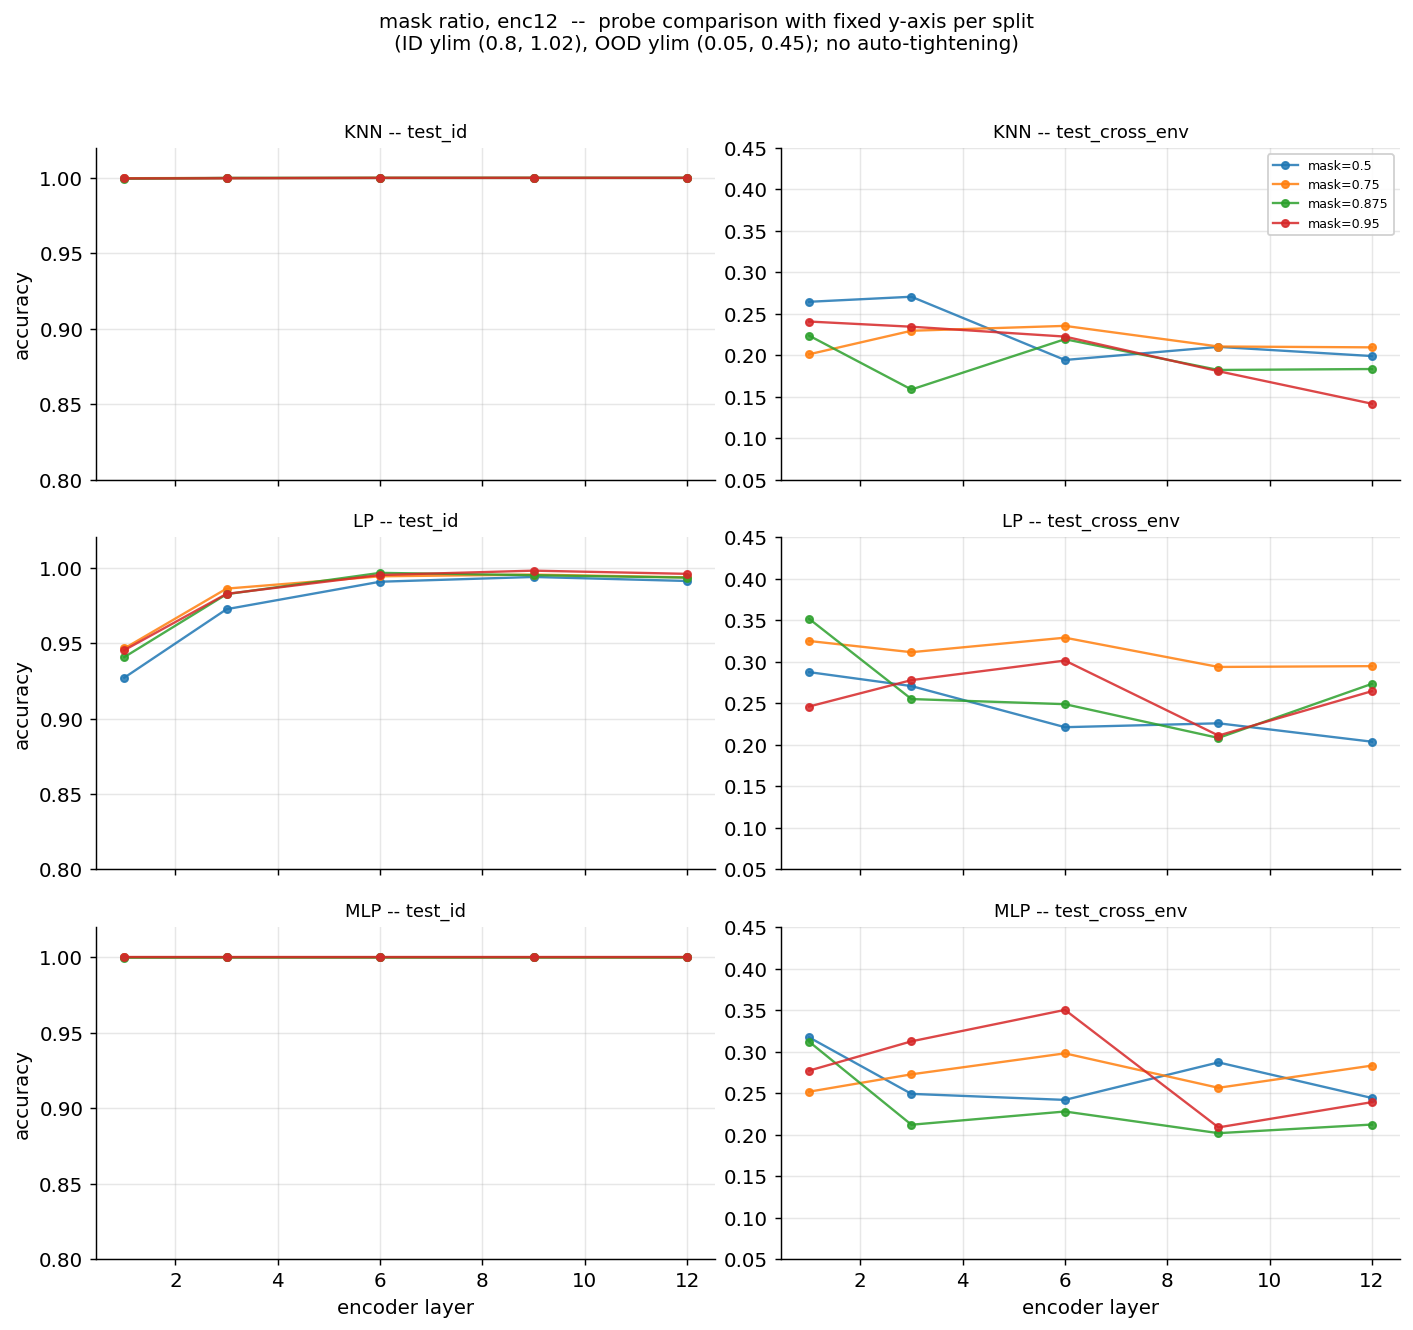

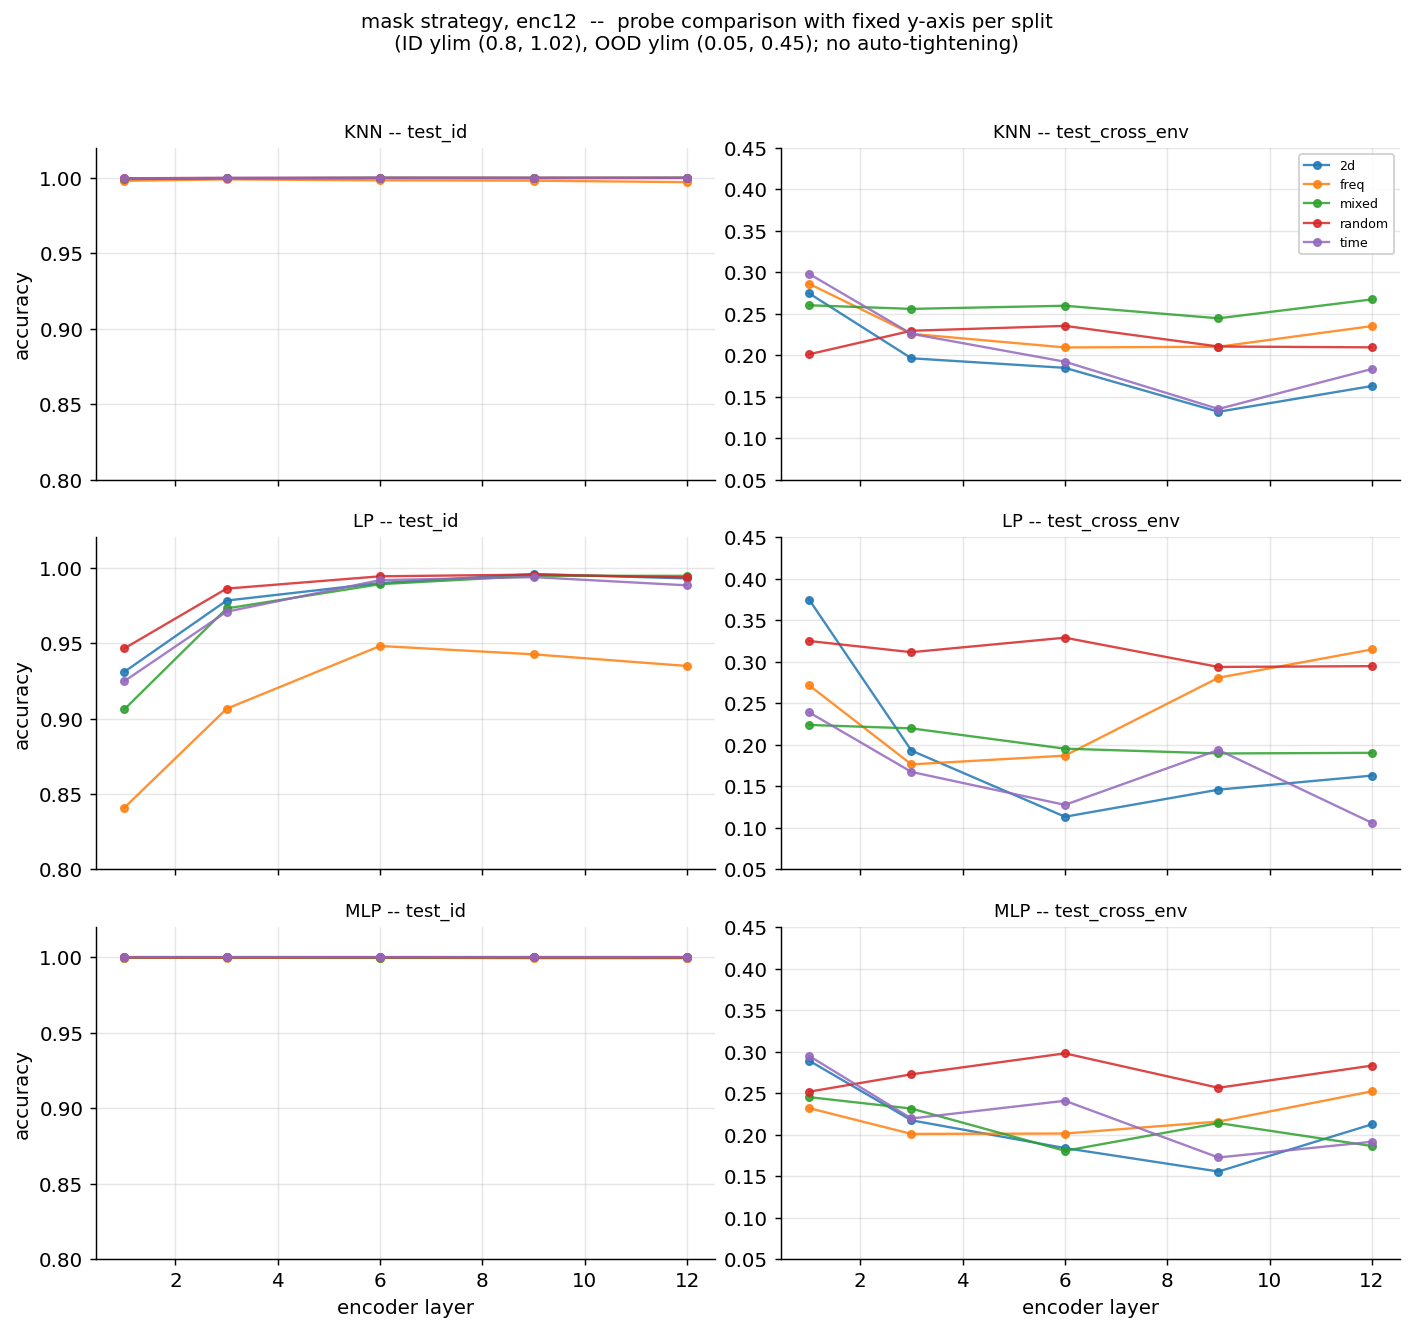

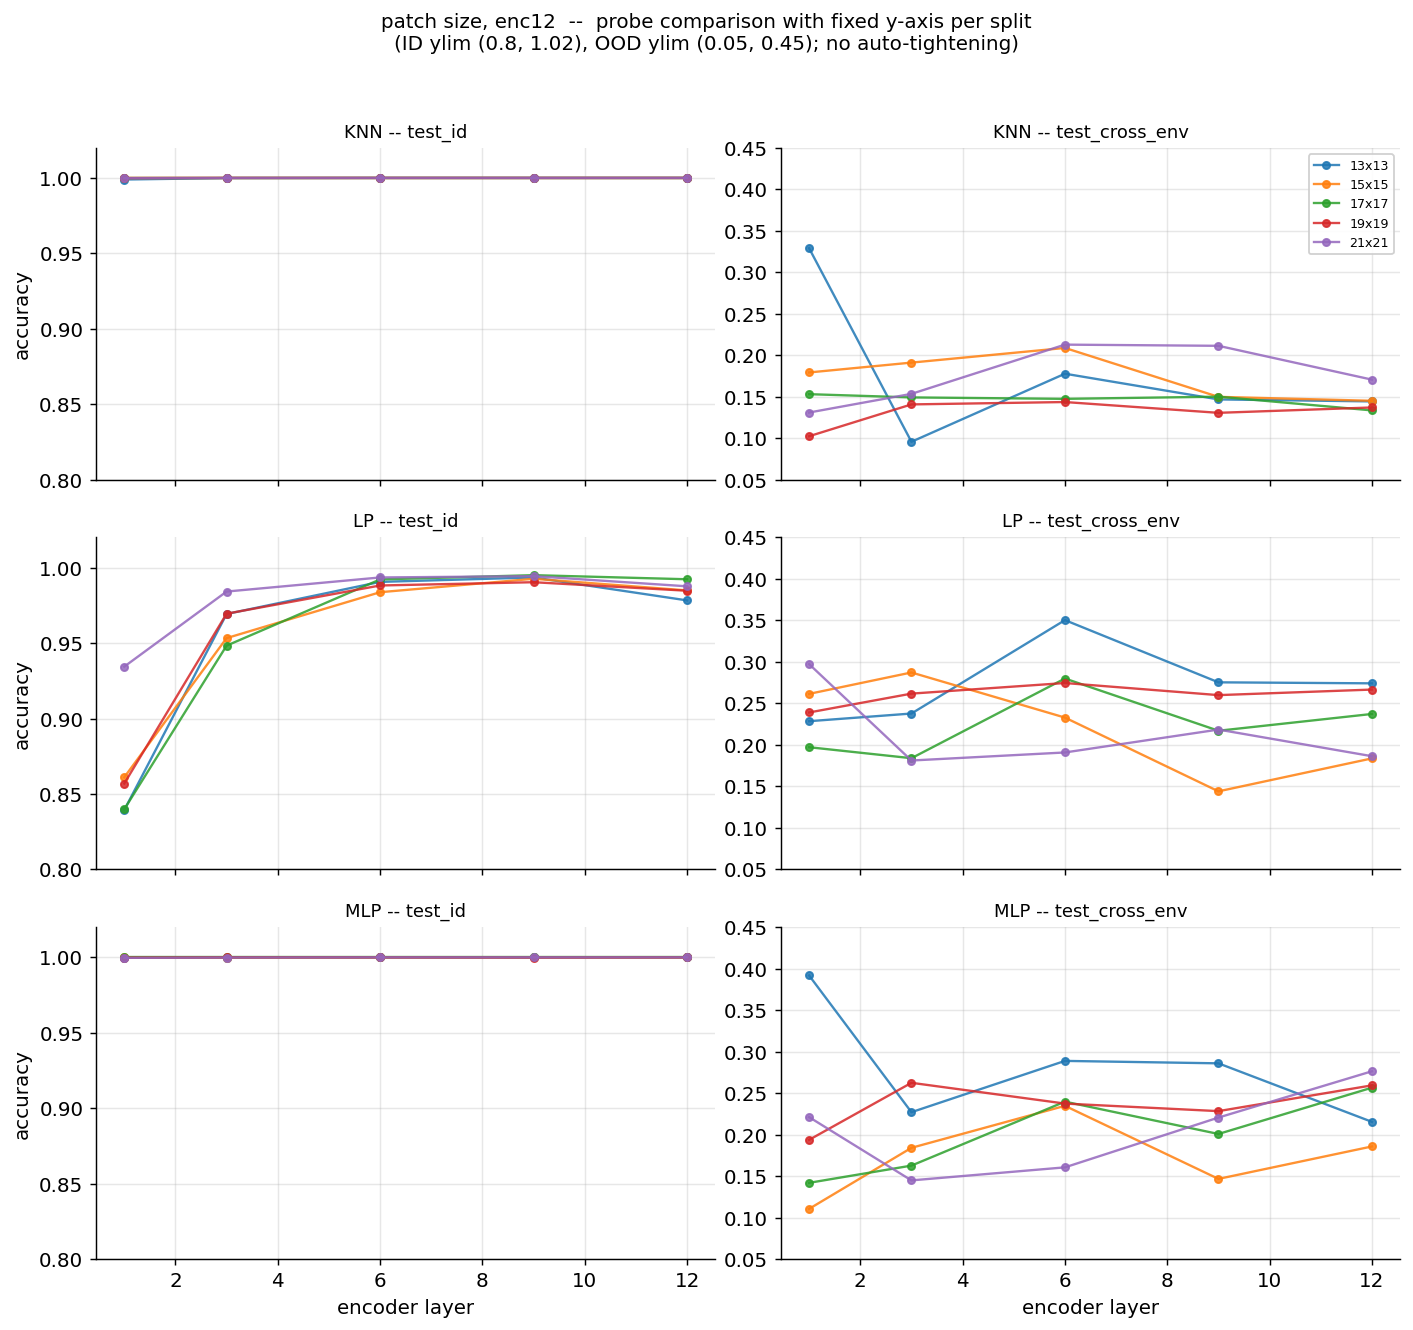

In [37]:
if a_groups:
    plot_probe_grid_fixed_ylim(a_groups, "mask ratio, enc12", group_label_fmt="mask={k}")
if d_groups:
    plot_probe_grid_fixed_ylim(d_groups, "mask strategy, enc12", group_label_fmt="{k}")
if e_groups:
    plot_probe_grid_fixed_ylim(e_groups, "patch size, enc12", group_label_fmt="{k}x{k}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

def compute_min_cosine_distance(X_train, X_test):
    """
    Computes the minimum cosine distance from each sample in X_test
    to its nearest neighbor in X_train.
    
    Cosine Distance = 1 - Cosine Similarity
    """
    nn = NearestNeighbors(n_neighbors=1, metric='cosine', n_jobs=-1)
    nn.fit(X_train)
    distances, _ = nn.kneighbors(X_test)
    return distances.ravel()


def plot_nearest_cosine_dist_comparison(
    X_train, X_test_id, X_test_cross_env, outdir, filename="cosine_dist_id_vs_cross_env.png"
):
    """
    Computes nearest-neighbor cosine distances for test_id and test_cross_env
    and plots their histogram/KDE distribution to inspect near-zero peaks.
    """
    # 1. Compute nearest neighbor cosine distances
    dist_id = compute_min_cosine_distance(X_train, X_test_id)
    dist_cross_env = compute_min_cosine_distance(X_train, X_test_cross_env)

    # 2. Print diagnostic statistics for near-zero values
    near_zero_thresh = 0.05
    id_near_zero_ratio = np.mean(dist_id < near_zero_thresh)
    cross_near_zero_ratio = np.mean(dist_cross_env < near_zero_thresh)

    print(f"[Diagnostic] Fraction of test_id samples with distance < {near_zero_thresh}: {id_near_zero_ratio:.4f}")
    print(f"[Diagnostic] Fraction of test_cross_env samples with distance < {near_zero_thresh}: {cross_near_zero_ratio:.4f}")

    # 3. Plot distribution histogram and density curve
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        dist_id, kde=True, stat="density", bins=50,
        color="tab:blue", alpha=0.35, label="test_id (In-Distribution)", ax=ax
    )
    sns.histplot(
        dist_cross_env, kde=True, stat="density", bins=50,
        color="tab:orange", alpha=0.35, label="test_cross_env (Cross-Env)", ax=ax
    )

    ax.set_xlabel("Nearest Neighbor Cosine Distance to Train")
    ax.set_ylabel("Density")
    ax.set_title("Nearest Neighbor Cosine Distance Distribution to Train Set")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=150, bbox_inches="tight")
    plt.show()

    return dist_id, dist_cross_env

In [ ]:
# Example Usage:
# Assume feature matrices: X_train, X_test_id, X_test_cross_env
dist_id, dist_cross_env = plot_nearest_cosine_dist_comparison(
    X_train=X_train,
    X_test_id=X_test_id,
    X_test_cross_env=X_test_cross_env,
    outdir=FIG_DIR,
    filename="cosine_dist_id_vs_cross_env.png"
)

## Notes / caveats (HID-specific)

- **`PRIMARY_METRICS` in Step 1 is a placeholder guess** -- the whole notebook downstream depends
  on it matching your real metric key names from Step 0's schema probe. If every section above
  prints "no data for metric=..." for all your metrics, this is almost certainly why: go back to
  Step 0's output and fix the list.
- **`test_cross_user` may be degenerate** (single held-out identity) per project notes: Rank-1
  trivially 100%, Verification AUC undefined (no negative pairs to compute AUC from). Don't treat
  a missing/NaN value there as a data-quality bug without checking this first.
- **Never max/argmax across different metrics** (e.g. never compare a Rank-1 percentage against a
  Verification AUC to decide which is "better") -- this notebook's `best_layer_for_metric` avoids
  that by construction (one metric per call), but if you extend this notebook, keep that separation.
- Same `n` caveat as the HAR notebook: check `n_seeds` in the printed tables before trusting a
  result -- `n=1` where you expect 2 (missing seed) or an unexpected number (filter picking up an
  unintended file) both warrant a second look.
